### Lade data functions

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
from mpl_toolkits.mplot3d import Axes3D

def load_dpca_results(filepath):
    """Safely load dPCA results"""
    try:
        # Load with pickle support
        data = np.load(filepath, allow_pickle=True)
        
        # Convert to dictionary if needed
        if isinstance(data, np.ndarray):
            results = data.item()
        else:
            results = data
            
        return results
        
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def load_specific_dates_results(results_dir, subject, dates):
    """
    Load dPCA results for specific dates and subject
    File pattern: zarya_20250417_MST_dpca_fullspike_stimOn_mod3_coh2_del0_results.npy
    """
    results_path = Path(results_dir)
    all_results = {}
    
    for date in dates:
        print(f"Loading data for {subject} on {date}...")
        
        # Look for files matching the pattern: subject_date_AREA_dpca_*_results.npy
        pattern = f"{subject}_{date}_*_dpca_*_results.npy"
        matching_files = list(results_path.glob(pattern))
        
        if not matching_files:
            print(f"  No files found for {subject} on {date}")
            continue
        
        # Group files by area and organize by condition/alignment
        date_results = {}
        
        for file_path in matching_files:
            print(f"  Loading {file_path.name}...")
            
            # Parse filename to extract info
            # Format: subject_date_area_dpca_fullspike_alignment_modX_cohY_del0_results.npy
            parts = file_path.stem.split('_')
            
            try:
                area = parts[2]  # MST, VPS, etc.
                alignment = parts[5]  # stimOn, saccOnset, postTargHold
                mod_part = parts[6]  # mod1, mod2, mod3
                coh_part = parts[7]  # coh1, coh2
                
                # Extract numbers
                mod = int(mod_part.replace('mod', ''))
                coh = int(coh_part.replace('coh', ''))
                
                condition_key = f"mod{mod}_coh{coh}"
                
                print(f"    Parsed: area={area}, alignment={alignment}, condition={condition_key}")
                
            except (IndexError, ValueError) as e:
                print(f"    Could not parse filename {file_path.name}: {e}")
                continue
            
            # Load the results
            session_result = load_dpca_results(file_path)
            if session_result is None:
                continue
            
            # Initialize nested structure
            if area not in date_results:
                date_results[area] = {}
            if condition_key not in date_results[area]:
                date_results[area][condition_key] = {}
            
            # Store the result
            date_results[area][condition_key][alignment] = session_result
        
        # Add to main results if we found data
        if date_results:
            session_key = f"{subject}_{date}"
            
            for area, area_data in date_results.items():
                if area not in all_results:
                    all_results[area] = {}
                all_results[area][session_key] = area_data
                print(f"    Added {area} area data for {session_key}")
    
    print(f"\nLoaded results for areas: {list(all_results.keys())}")
    for area, sessions in all_results.items():
        print(f"  {area}: {len(sessions)} sessions")
        for session_key, session_data in sessions.items():
            conditions = list(session_data.keys())
            print(f"    {session_key}: {conditions}")
    
    return all_results

### Stacked bar for variances

Loading all dPCA results...
Areas found: ['dual', 'MST', 'VPS']
  dual: 6 sessions
  MST: 6 sessions
  VPS: 6 sessions

Creating plot for MST area...
Sessions available: 6
Plot saved to: D:\Neural-Pipeline\results\analysis_population\dpca_results\dpca_stacked_bar_MST_area_absolute_SEM.png


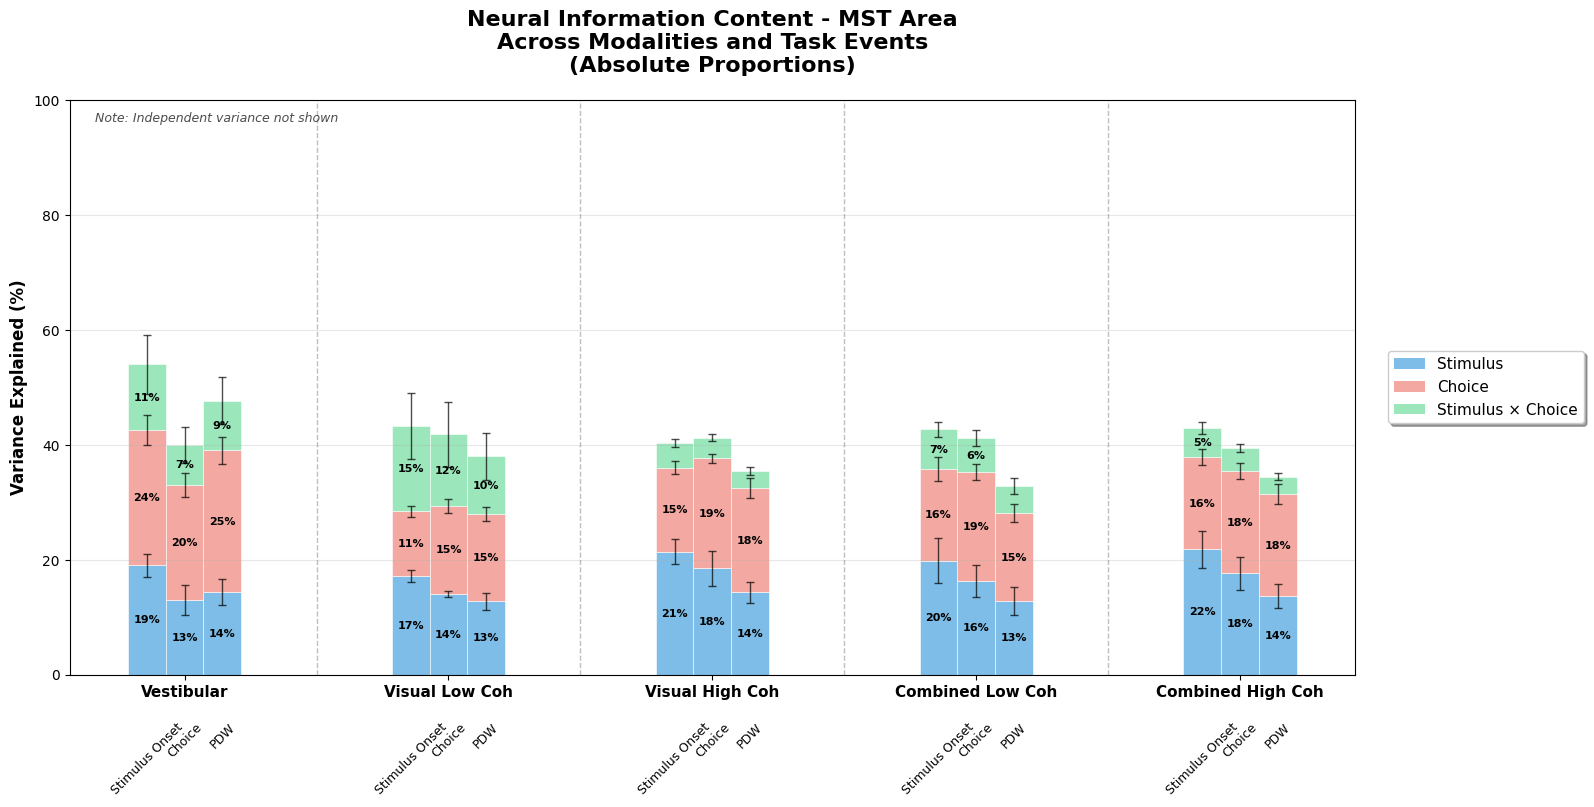


Creating plot for VPS area...
Sessions available: 6
Plot saved to: D:\Neural-Pipeline\results\analysis_population\dpca_results\dpca_stacked_bar_VPS_area_absolute_SEM.png


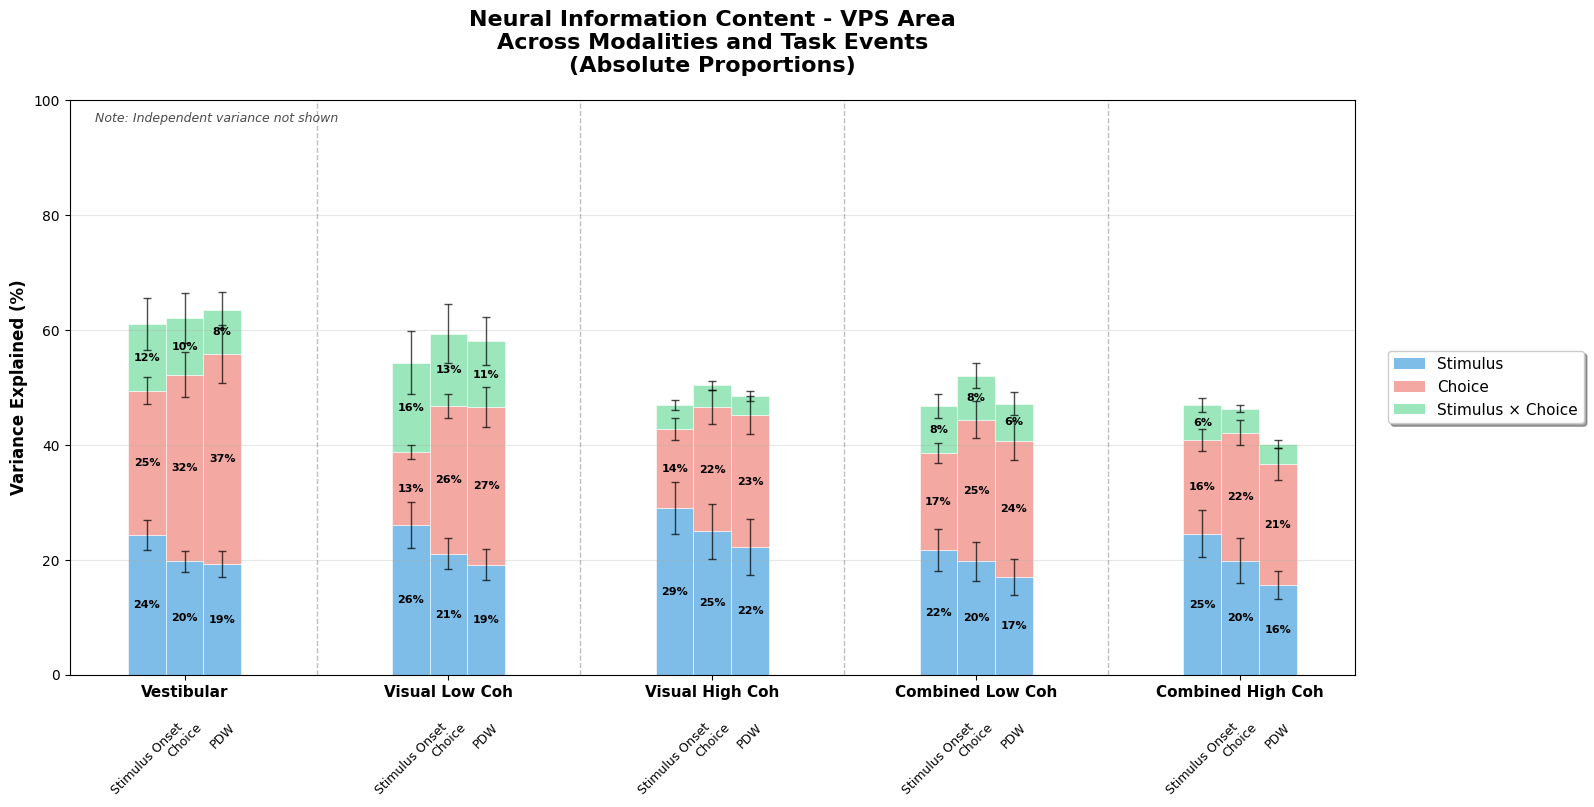


Creating plot for dual area...
Sessions available: 6
Plot saved to: D:\Neural-Pipeline\results\analysis_population\dpca_results\dpca_stacked_bar_dual_area_absolute_SEM.png


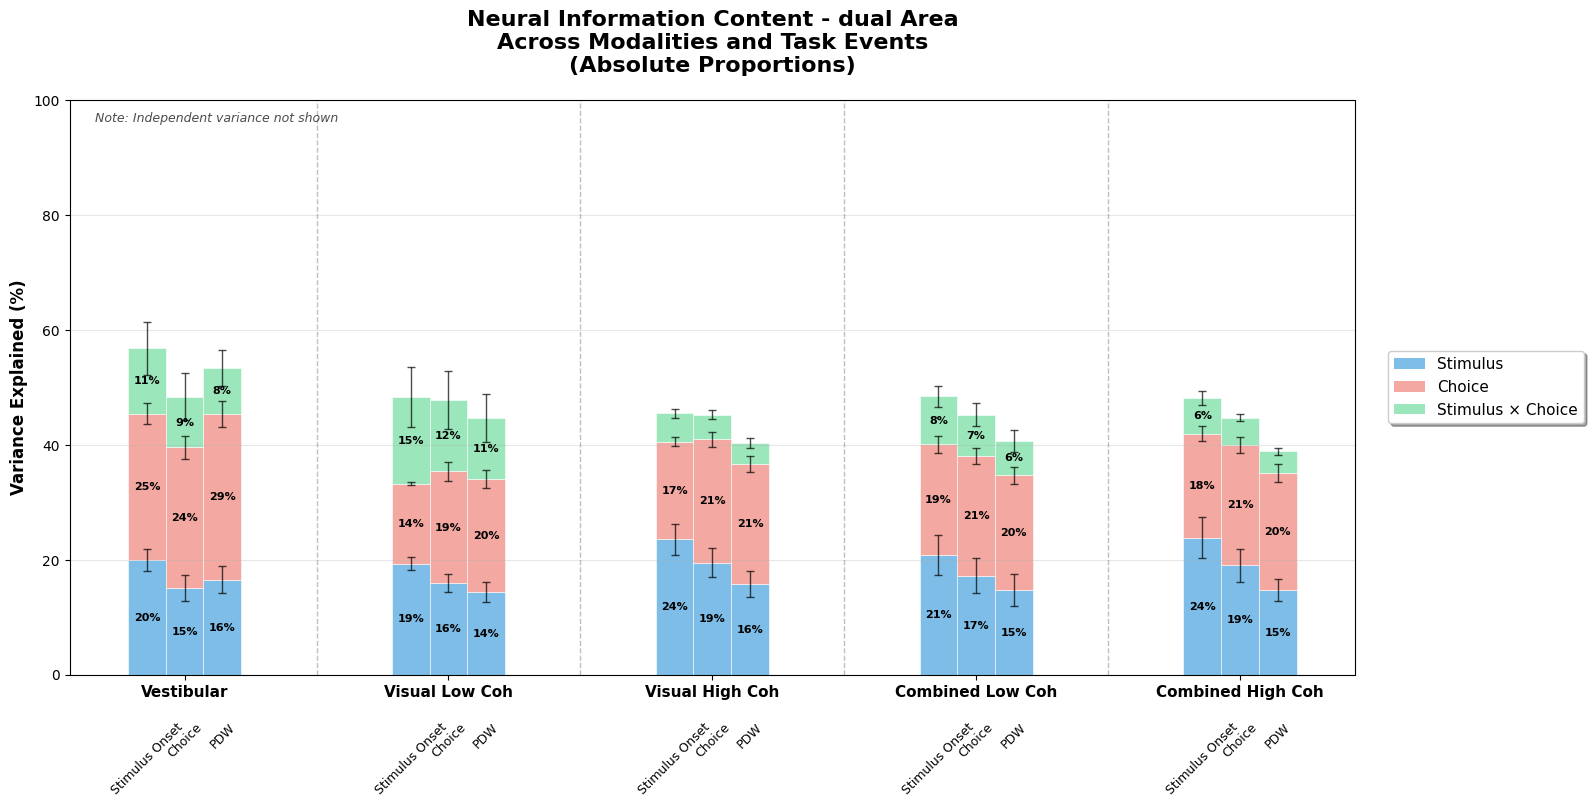


Created plots with absolute proportions and SEM for areas: ['MST', 'VPS', 'dual']


In [9]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def load_all_dpca_results(results_dir):
    """
    Load all dPCA results from directory, organized by brain area
    """
    results_dir = Path(results_dir)
    all_results = {}
    
    # Search for files matching the pattern
    for results_file in results_dir.glob("*_dpca_fullspike_*.npy"):
        try:
            # Parse filename to extract conditions
            filename = results_file.stem
            parts = filename.split('_')
            
            # Extract subject, date, area, alignment, and conditions
            subject = parts[0]
            date = parts[1] 
            area = parts[2]
            alignment = None
            mod = None
            coh = None
            
            # Find alignment and conditions in filename
            for i, part in enumerate(parts):
                if part in ['stimOn', 'saccOnset', 'postTargHold']:
                    alignment = part
                elif part.startswith('mod') and len(part) > 3:
                    mod = int(part[3:])
                elif part.startswith('coh') and len(part) > 3:
                    coh = int(part[3:])
            
            if alignment and mod and coh is not None:
                # Load the results
                data = np.load(results_file, allow_pickle=True).item()
                
                # Organize by area first
                if area not in all_results:
                    all_results[area] = {}
                
                # Store in nested dictionary
                session_key = f"{subject}_{date}_{area}"
                if session_key not in all_results[area]:
                    all_results[area][session_key] = {}
                
                condition_key = f"mod{mod}_coh{coh}"
                if condition_key not in all_results[area][session_key]:
                    all_results[area][session_key][condition_key] = {}
                
                all_results[area][session_key][condition_key][alignment] = data
                
        except Exception as e:
            print(f"Error loading {results_file}: {e}")
            continue
    
    return all_results

def calculate_grouped_variances_absolute(variance_explained):
    """
    Group variance explained into categories with ABSOLUTE percentages
    (not renormalized after removing Independent)
    """
    # First calculate all categories including Independent
    all_categories = {
        'Stimulus': 0,              # s + ts
        'Choice': 0,                # d + td  
        'Stimulus × Choice': 0,     # sd + tsd
        'Independent': 0            # t (calculated but not plotted)
    }
    
    # Group marginalizations
    if 's' in variance_explained:
        all_categories['Stimulus'] += sum(variance_explained['s'])
    if 'ts' in variance_explained:
        all_categories['Stimulus'] += sum(variance_explained['ts'])
        
    if 'd' in variance_explained:
        all_categories['Choice'] += sum(variance_explained['d'])
    if 'td' in variance_explained:
        all_categories['Choice'] += sum(variance_explained['td'])
        
    if 'sd' in variance_explained:
        all_categories['Stimulus × Choice'] += sum(variance_explained['sd'])
    if 'tsd' in variance_explained:
        all_categories['Stimulus × Choice'] += sum(variance_explained['tsd'])
        
    if 't' in variance_explained:
        all_categories['Independent'] += sum(variance_explained['t'])
    
    # Convert to percentages using TOTAL variance (including Independent)
    total_var = sum(all_categories.values())
    if total_var > 0:
        for key in all_categories:
            all_categories[key] = (all_categories[key] / total_var) * 100
    
    # Return only the categories we want to plot (excluding Independent)
    plotted_categories = {
        'Stimulus': all_categories['Stimulus'],
        'Choice': all_categories['Choice'],
        'Stimulus × Choice': all_categories['Stimulus × Choice']
    }
    
    return plotted_categories

def create_area_specific_stacked_bar_plot(area_results, area_name, save_path=None):
    """
    Create stacked bar plot with SEM error bars above each segment and absolute proportions
    """
    
    # Define condition mapping
    condition_mapping = {
        'mod1_coh1': 'Vestibular',
        'mod2_coh1': 'Visual Low Coh', 
        'mod2_coh2': 'Visual High Coh',
        'mod3_coh1': 'Combined Low Coh',
        'mod3_coh2': 'Combined High Coh'
    }
    
    alignment_mapping = {
        'stimOn': 'Stimulus Onset',
        'saccOnset': 'Choice',
        'postTargHold': 'PDW'
    }
    
    # Updated colors (only 3 categories, removed Independent)
    colors = {
        'Stimulus': '#5DADE2',          # Light blue (bottom)
        'Choice': '#F1948A',            # Light red/coral (middle)
        'Stimulus × Choice': '#82E0AA', # Light green (top)
    }
    
    conditions = list(condition_mapping.keys())
    alignments = list(alignment_mapping.keys())
    
    # Create single figure
    fig, ax = plt.subplots(1, 1, figsize=(16, 8))
    
    # Calculate positions for grouped bars
    n_conditions = len(conditions)
    n_alignments = len(alignments)
    
    # Bar width and spacing
    bar_width = 0.25
    group_spacing = 1.0  # Space between modality groups
    
    # Calculate x positions
    x_positions = []
    group_centers = []
    alignment_labels = []
    
    for cond_idx in range(n_conditions):
        group_center = cond_idx * (n_alignments * bar_width + group_spacing)
        group_centers.append(group_center + bar_width)
        
        for align_idx in range(n_alignments):
            x_pos = group_center + align_idx * bar_width
            x_positions.append(x_pos)
            alignment_labels.append(alignments[align_idx])
    
    # Collect all data WITH individual session values for SEM calculation
    all_data_means = []
    all_data_sems = []
    
    for cond_idx, condition in enumerate(conditions):
        for align_idx, alignment in enumerate(alignments):
            # Collect data across all sessions for this condition/alignment in this area
            session_variances = []
            
            for session_key, session_data in area_results.items():
                if condition in session_data and alignment in session_data[condition]:
                    variance_explained = session_data[condition][alignment]['variance_explained']
                    grouped_var = calculate_grouped_variances_absolute(variance_explained)
                    session_variances.append(grouped_var)
            
            if session_variances:
                # Calculate means and SEM across sessions
                means = {}
                sems = {}
                n_sessions = len(session_variances)
                
                for info_type in ['Stimulus', 'Choice', 'Stimulus × Choice']:
                    values = [sv[info_type] for sv in session_variances if info_type in sv]
                    means[info_type] = np.mean(values) if values else 0
                    # Calculate SEM = std / sqrt(n)
                    if len(values) > 1:
                        sems[info_type] = np.std(values) / np.sqrt(len(values))
                    else:
                        sems[info_type] = 0
                
                all_data_means.append(means)
                all_data_sems.append(sems)
            else:
                # No data - set to zeros
                means = {info_type: 0 for info_type in colors.keys()}
                sems = {info_type: 0 for info_type in colors.keys()}
                all_data_means.append(means)
                all_data_sems.append(sems)
    
    # Create stacked bars with SEM error bars ABOVE each segment
    bottoms = np.zeros(len(all_data_means))
    
    # Plot each information type as a stack
    for info_type in ['Stimulus', 'Choice', 'Stimulus × Choice']:  # Bottom to top order
        values = np.array([data[info_type] for data in all_data_means])
        errors = np.array([data[info_type] for data in all_data_sems])
        
        # Create the stacked bars
        bars = ax.bar(x_positions, values, bar_width, bottom=bottoms, 
                     color=colors[info_type], label=info_type, alpha=0.8, 
                     edgecolor='white', linewidth=0.5)
        
        # Add SEM error bars ABOVE each segment
        error_positions = bottoms + values  # Top of each segment
        
        # Only add error bars if there are multiple sessions (SEM > 0)
        for i, (x_pos, error_pos, error_val) in enumerate(zip(x_positions, error_positions, errors)):
            if error_val > 0:  # Only plot if there's actual variance
                ax.errorbar(x_pos, error_pos, yerr=error_val, 
                           fmt='none', color='black', capsize=3, capthick=1, 
                           linewidth=1, alpha=0.7)
        
        # Add percentage labels on bars (if segment is large enough)
        for i, (bar, value) in enumerate(zip(bars, values)):
            if value > 5:  # Only label if segment is > 5% (lower threshold since bars are smaller now)
                height = bar.get_height()
                text_y = bottoms[i] + height/2
                ax.text(bar.get_x() + bar.get_width()/2., text_y,
                       f'{value:.0f}%', ha='center', va='center', 
                       fontweight='bold', fontsize=8, color='black')
        
        # Update bottom positions for next stack
        bottoms += values
    
    # Customize x-axis
    ax.set_xticks(group_centers)
    ax.set_xticklabels([condition_mapping[cond] for cond in conditions], 
                       fontsize=11, fontweight='bold')
    
    # Add alignment labels below each bar
    for i, (x_pos, alignment) in enumerate(zip(x_positions, alignment_labels)):
        alignment_name = alignment_mapping[alignment]
        ax.text(x_pos, -8, alignment_name, ha='center', va='top', 
               fontsize=9, rotation=45)
    
    # Add vertical lines to separate modality groups
    for i in range(1, n_conditions):
        separator_x = group_centers[i] - (bar_width * n_alignments/2 + group_spacing/2)
        ax.axvline(x=separator_x, color='gray', linestyle='--', alpha=0.5, linewidth=1)
    
    # Customize plot
    ax.set_ylabel('Variance Explained (%)', fontsize=12, fontweight='bold')
    ax.set_ylim(0, 100)  # Keep 100% scale even though bars won't reach 100%
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_title(f'Neural Information Content - {area_name} Area\nAcross Modalities and Task Events\n(Absolute Proportions)', 
                fontsize=16, fontweight='bold', pad=20)
    
    # Create legend outside the plot
    legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[info_type], 
                                   label=info_type, alpha=0.8) 
                      for info_type in ['Stimulus', 'Choice', 'Stimulus × Choice']]
    ax.legend(handles=legend_elements, loc='center left', bbox_to_anchor=(1.02, 0.5), 
             fontsize=11, frameon=True, fancybox=True, shadow=True)
    
    # Add note about Independent variance not shown
    ax.text(0.02, 0.98, 'Note: Independent variance not shown', 
           transform=ax.transAxes, fontsize=9, style='italic', 
           verticalalignment='top', alpha=0.7)
    
    # Adjust layout to accommodate legend
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.15, right=0.85)
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved to: {save_path}")
    
    plt.show()
    
    return fig

def create_all_area_plots(all_results, results_dir):
    """
    Create separate plots for each brain area
    """
    
    # Define areas to plot
    target_areas = ['MST', 'VPS', 'dual']
    
    figures = {}
    
    for area in target_areas:
        if area in all_results:
            print(f"\nCreating plot for {area} area...")
            print(f"Sessions available: {len(all_results[area])}")
            
            # Create plot for this area
            save_path = Path(results_dir) / f"dpca_stacked_bar_{area}_area_absolute_SEM.png"
            fig = create_area_specific_stacked_bar_plot(all_results[area], area, save_path)
            figures[area] = fig
            
        else:
            print(f"No data found for {area} area")
    
    return figures

# Load and plot the data
results_dir = r"D:\Neural-Pipeline\results\analysis_population\dpca_results"
print("Loading all dPCA results...")
all_results = load_all_dpca_results(results_dir)

print(f"Areas found: {list(all_results.keys())}")
for area, area_data in all_results.items():
    print(f"  {area}: {len(area_data)} sessions")

# Create plots for each area
figures = create_all_area_plots(all_results, results_dir)

print(f"\nCreated plots with absolute proportions and SEM for areas: {list(figures.keys())}")

### PC1 and PC2 as the function of time

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
from mpl_toolkits.mplot3d import Axes3D

def load_dpca_results(filepath):
    """Safely load dPCA results"""
    try:
        # Load with pickle support
        data = np.load(filepath, allow_pickle=True)
        
        # Convert to dictionary if needed
        if isinstance(data, np.ndarray):
            results = data.item()
        else:
            results = data
            
        return results
        
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def load_specific_dates_results(results_dir, subject, dates):
    """
    Load dPCA results for specific dates and subject
    File pattern: zarya_20250417_MST_dpca_fullspike_stimOn_mod3_coh2_del0_results.npy
    """
    results_path = Path(results_dir)
    all_results = {}
    
    for date in dates:
        print(f"Loading data for {subject} on {date}...")
        
        # Look for files matching the pattern: subject_date_AREA_dpca_*_results.npy
        pattern = f"{subject}_{date}_*_dpca_*_results.npy"
        matching_files = list(results_path.glob(pattern))
        
        if not matching_files:
            print(f"  No files found for {subject} on {date}")
            continue
        
        # Group files by area and organize by condition/alignment
        date_results = {}
        
        for file_path in matching_files:
            print(f"  Loading {file_path.name}...")
            
            # Parse filename to extract info
            # Format: subject_date_area_dpca_fullspike_alignment_modX_cohY_del0_results.npy
            parts = file_path.stem.split('_')
            
            try:
                area = parts[2]  # MST, VPS, etc.
                alignment = parts[5]  # stimOn, saccOnset, postTargHold
                mod_part = parts[6]  # mod1, mod2, mod3
                coh_part = parts[7]  # coh1, coh2
                
                # Extract numbers
                mod = int(mod_part.replace('mod', ''))
                coh = int(coh_part.replace('coh', ''))
                
                condition_key = f"mod{mod}_coh{coh}"
                
                print(f"    Parsed: area={area}, alignment={alignment}, condition={condition_key}")
                
            except (IndexError, ValueError) as e:
                print(f"    Could not parse filename {file_path.name}: {e}")
                continue
            
            # Load the results
            session_result = load_dpca_results(file_path)
            if session_result is None:
                continue
            
            # Initialize nested structure
            if area not in date_results:
                date_results[area] = {}
            if condition_key not in date_results[area]:
                date_results[area][condition_key] = {}
            
            # Store the result
            date_results[area][condition_key][alignment] = session_result
        
        # Add to main results if we found data
        if date_results:
            session_key = f"{subject}_{date}"
            
            for area, area_data in date_results.items():
                if area not in all_results:
                    all_results[area] = {}
                all_results[area][session_key] = area_data
                print(f"    Added {area} area data for {session_key}")
    
    print(f"\nLoaded results for areas: {list(all_results.keys())}")
    for area, sessions in all_results.items():
        print(f"  {area}: {len(sessions)} sessions")
        for session_key, session_data in sessions.items():
            conditions = list(session_data.keys())
            print(f"    {session_key}: {conditions}")
    
    return all_results

def plot_dpca_trajectories_3d_time_first(all_results, results_dir, subject):
    """
    Plot dPCA components as 3D trajectories (Time, PC2, PC1) for individual sessions
    """
    
    # Define stimulus-specific colors based on DIRECTION (blue = rightward, red = leftward)
    stimulus_colors = {
        1: "#8B0000",    # -10° - dark red (strong leftward)
        2: "#DC143C",    # -3.9° - medium red (medium leftward)  
        3: "#FF6B6B",    # -1.5° - light red (weak leftward)
        4: "#808080",    # 0° - gray (neutral)
        5: "#94C8FF",    # +1.5° - light blue (weak rightward)
        6: "#1E90FF",    # +3.9° - medium blue (medium rightward)
        7: "#0000CF"     # +10° - dark blue (strong rightward)
    }
    
    # Define condition mapping
    modality_conditions = {
        'Vestibular': {'mod': 1, 'coh': 1},
        'Visual Low Coh': {'mod': 2, 'coh': 1},
        'Visual High Coh': {'mod': 2, 'coh': 2},
        'Combined Low Coh': {'mod': 3, 'coh': 1},
        'Combined High Coh': {'mod': 3, 'coh': 2}
    }
    
    alignments = ['stimOn', 'saccOnset', 'postTargHold']
    alignment_names = {
        'stimOn': 'Stimulus Onset',
        'saccOnset': 'Choice',
        'postTargHold': 'PDW'
    }
    
    # Component types to plot
    component_types = ['s', 'ts', 'd', 'td']
    component_names = {
        's': 'Stimulus',
        'ts': 'Time-Stimulus', 
        'd': 'Choice',
        'td': 'Time-Choice'
    }
    
    # Define areas to plot
    target_areas = ['MST', 'VPS', 'dual']
    
    for area in target_areas:
        if area not in all_results:
            print(f"No data found for {area} area")
            continue
            
        print(f"\nCreating 3D trajectory dPCA plots for {area} area...")
        
        # Process each session individually
        for session_key, session_data in all_results[area].items():
            print(f"\n  Processing session: {session_key}")
            
            # Create separate figure for each component type for this session
            for comp_type in component_types:
                print(f"    Processing {comp_type} component...")
                
                # Create figure: 5 conditions x 3 alignments
                fig = plt.figure(figsize=(22, 25))
                
                subplot_idx = 1
                has_data = False
                
                for i, (condition_name, condition_params) in enumerate(modality_conditions.items()):
                    mod = condition_params['mod']
                    coh = condition_params['coh']
                    condition_key = f"mod{mod}_coh{coh}"
                    
                    for j, alignment in enumerate(alignments):
                        ax = fig.add_subplot(5, 3, subplot_idx, projection='3d')
                        subplot_idx += 1
                        
                        if condition_key not in session_data or alignment not in session_data[condition_key]:
                            ax.text(0.5, 0.5, 0.5, f'No data', ha='center', va='center', 
                                   transform=ax.transAxes, fontsize=10)
                            continue
                        
                        dpca_result = session_data[condition_key][alignment]
                        
                        if comp_type not in dpca_result['Z_components']:
                            ax.text(0.5, 0.5, 0.5, f'No {comp_type}\ncomponent', ha='center', va='center', 
                                   transform=ax.transAxes, fontsize=10)
                            continue
                            
                        # Get first two components
                        components = dpca_result['Z_components'][comp_type]
                        if len(components) < 2:
                            ax.text(0.5, 0.5, 0.5, f'Less than 2\ncomponents', ha='center', va='center', 
                                   transform=ax.transAxes, fontsize=10)
                            continue
                            
                        pc1 = components[0]  # (n_time, n_stimuli, n_choices)
                        pc2 = components[1]
                        time_axis = dpca_result['time_axes']
                        
                        has_data = True
                        
                        # Plot each stimulus heading (1-7)
                        for heading_idx in range(1, 8):  # Headings 1-7
                            if heading_idx > pc1.shape[1]:
                                continue
                            
                            color = stimulus_colors[heading_idx]
                            heading_deg = [-10, -3.9, -1.5, 0, 1.5, 3.9, 10][heading_idx-1]
                            
                            if heading_idx == 4:  # Zero heading - only one trajectory
                                # Average across choices for zero heading
                                pc1_data = np.mean(pc1[:, heading_idx-1, :], axis=1)
                                pc2_data = np.mean(pc2[:, heading_idx-1, :], axis=1)
                                
                                # Plot 3D trajectory (Time, PC2, PC1)
                                ax.plot(time_axis, pc2_data, pc1_data, color=color, linewidth=2, 
                                       alpha=0.7, label=f'{heading_deg}°')
                                
                                # Mark alignment point (t=0)
                                t0_idx = np.argmin(np.abs(time_axis))
                                ax.scatter(time_axis[t0_idx], pc2_data[t0_idx], pc1_data[t0_idx], 
                                         color=color, s=60, marker='o', edgecolors='black', linewidth=1)
                                
                                # Mark start and end
                                ax.scatter(time_axis[0], pc2_data[0], pc1_data[0], 
                                         color=color, s=40, marker='s', alpha=0.8)
                                ax.scatter(time_axis[-1], pc2_data[-1], pc1_data[-1], 
                                         color=color, s=40, marker='^', alpha=0.8)
                            
                            else:  # Non-zero headings - correct and error trials
                                # Determine correct choice for this heading
                                if heading_idx <= 3:  # Negative headings (1,2,3) - leftward direction
                                    correct_choice = 0  # Left choice is correct
                                    error_choice = 1    # Right choice is error
                                else:  # Positive headings (5,6,7) - rightward direction
                                    correct_choice = 1  # Right choice is correct  
                                    error_choice = 0    # Left choice is error
                                
                                # Get data for correct and error trials
                                pc1_correct = pc1[:, heading_idx-1, correct_choice]
                                pc2_correct = pc2[:, heading_idx-1, correct_choice]
                                pc1_error = pc1[:, heading_idx-1, error_choice]
                                pc2_error = pc2[:, heading_idx-1, error_choice]
                                
                                # Plot correct trials (solid line) - (Time, PC2, PC1)
                                ax.plot(time_axis, pc2_correct, pc1_correct, color=color, linewidth=2.5, 
                                       linestyle='-', alpha=0.8,
                                       label=f'{heading_deg}° Correct')
                                
                                # Plot error trials (dashed line) - (Time, PC2, PC1)
                                ax.plot(time_axis, pc2_error, pc1_error, color=color, linewidth=2, 
                                       linestyle='--', alpha=0.6,
                                       label=f'{heading_deg}° Error')
                                
                                # Mark alignment points (t=0)
                                t0_idx = np.argmin(np.abs(time_axis))
                                ax.scatter(time_axis[t0_idx], pc2_correct[t0_idx], pc1_correct[t0_idx], 
                                         color=color, s=60, marker='o', edgecolors='black', linewidth=1)
                                ax.scatter(time_axis[t0_idx], pc2_error[t0_idx], pc1_error[t0_idx], 
                                         color=color, s=60, marker='o', edgecolors='black', linewidth=1, alpha=0.6)
                                
                                # Mark start and end for correct trials
                                ax.scatter(time_axis[0], pc2_correct[0], pc1_correct[0], 
                                         color=color, s=40, marker='s', alpha=0.8)
                                ax.scatter(time_axis[-1], pc2_correct[-1], pc1_correct[-1], 
                                         color=color, s=40, marker='^', alpha=0.8)
                                
                                # Mark start and end for error trials
                                ax.scatter(time_axis[0], pc2_error[0], pc1_error[0], 
                                         color=color, s=30, marker='s', alpha=0.6)
                                ax.scatter(time_axis[-1], pc2_error[-1], pc1_error[-1], 
                                         color=color, s=30, marker='^', alpha=0.6)
                        
                        # Add alignment plane at t=0
                        if len(time_axis) > 0:
                            ylims = ax.get_ylim()  # PC2 limits
                            zlims = ax.get_zlim()  # PC1 limits
                            yy, zz = np.meshgrid(np.linspace(ylims[0], ylims[1], 10), 
                                               np.linspace(zlims[0], zlims[1], 10))
                            xx = np.zeros_like(yy)  # t=0 plane
                            ax.plot_surface(xx, yy, zz, alpha=0.1, color='gray')
                        
                        # Formatting (Time, PC2, PC1)
                        ax.set_xlabel('Time (s)')
                        ax.set_ylabel(f'{comp_type.upper()} PC2')
                        ax.set_zlabel(f'{comp_type.upper()} PC1')
                        
                        # Title for top row
                        if i == 0:
                            ax.set_title(f'{alignment_names[alignment]}', fontsize=14, fontweight='bold')
                        
                        # Condition label for leftmost column
                        if j == 0:
                            ax.text2D(-0.15, 0.5, condition_name, rotation=90, 
                                   verticalalignment='center', horizontalalignment='center',
                                   transform=ax.transAxes, fontsize=12, fontweight='bold')
                        
                        ax.grid(True, alpha=0.3)
                
                if not has_data:
                    plt.close(fig)
                    continue
                
                # Create legend outside the plots
                from matplotlib.lines import Line2D
                legend_elements = [
                    Line2D([0], [0], color='black', linewidth=2, linestyle='-', label='Correct Trials'),
                    Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Error Trials'),
                    Line2D([0], [0], color='#0000CF', linewidth=2, label='Rightward Direction'),
                    Line2D([0], [0], color='#808080', linewidth=2, label='Zero'),
                    Line2D([0], [0], color='#8B0000', linewidth=2, label='Leftward Direction'),
                    Line2D([0], [0], color='black', marker='s', linestyle='None', markersize=6, label='Start'),
                    Line2D([0], [0], color='black', marker='o', linestyle='None', markersize=8, label='Alignment'),
                    Line2D([0], [0], color='black', marker='^', linestyle='None', markersize=6, label='End')
                ]
                
                # Position legend outside the plot area
                fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(0.98, 0.5), 
                          fontsize=10, frameon=True, fancybox=True, shadow=True)
                
                # Overall title
                fig.suptitle(f'{component_names[comp_type]} Component: 3D Trajectories (Time vs PC2 vs PC1) - {area} Area\n'
                            f'Subject: {subject}, Session: {session_key}\n'
                            f'Solid=Correct, Dashed=Error, Blue=Rightward, Red=Leftward', 
                             fontsize=14, y=0.98)
                
                plt.tight_layout()
                plt.subplots_adjust(top=0.92, left=0.05, right=0.85)
                
                # Save figure with session-specific filename
                save_filename = Path(results_dir) / f"{subject}_{session_key}_dpca_{comp_type}_3d_trajectories_{area}_area.png"
                plt.savefig(save_filename, dpi=300, bbox_inches='tight')
                print(f"      Figure saved as: {save_filename}")
                
                plt.show()

# Set parameters and run
results_dir = r"D:\Neural-Pipeline\results\analysis_population\dpca_results"
subject = "zarya"
dates = ["20250602", "20250702", "20250710", "20250523", "20250501", "20250417"]

# Load results for specific dates
print(f"Loading dPCA results for {subject}...")
all_results = load_specific_dates_results(results_dir, subject, dates)

# Plot 3D trajectories with time as first axis
plot_dpca_trajectories_3d_time_first(all_results, results_dir, subject)

### Angles between stimulus and choice

Loading dPCA results...
Loading data for zarya on 20250602...
Loading data for zarya on 20250702...
Loading data for zarya on 20250710...
Loading data for zarya on 20250523...
Loading data for zarya on 20250501...
Loading data for zarya on 20250417...

Calculating pooled angle summary for MST area...
  Processing Vestibular for stimOn...
    Early: 67.2° ± 13.7° (n=6)
    Late: 68.6° ± 10.9° (n=6)
  Processing Visual Low Coh for stimOn...
    Early: 66.1° ± 10.9° (n=6)
    Late: 65.3° ± 17.0° (n=6)
  Processing Visual High Coh for stimOn...
    Early: 63.5° ± 18.0° (n=6)
    Late: 67.4° ± 14.8° (n=6)
  Processing Combined Low Coh for stimOn...
    Early: 64.0° ± 13.9° (n=6)
    Late: 74.7° ± 5.2° (n=6)
  Processing Combined High Coh for stimOn...
    Early: 70.6° ± 9.0° (n=6)
    Late: 70.9° ± 8.0° (n=6)
  Processing Vestibular for saccOnset...
    Pre-Choice: 69.9° ± 10.6° (n=6)
    Choice: 75.0° ± 8.4° (n=6)
  Processing Visual Low Coh for saccOnset...
    Pre-Choice: 68.5° ± 7.7° (n

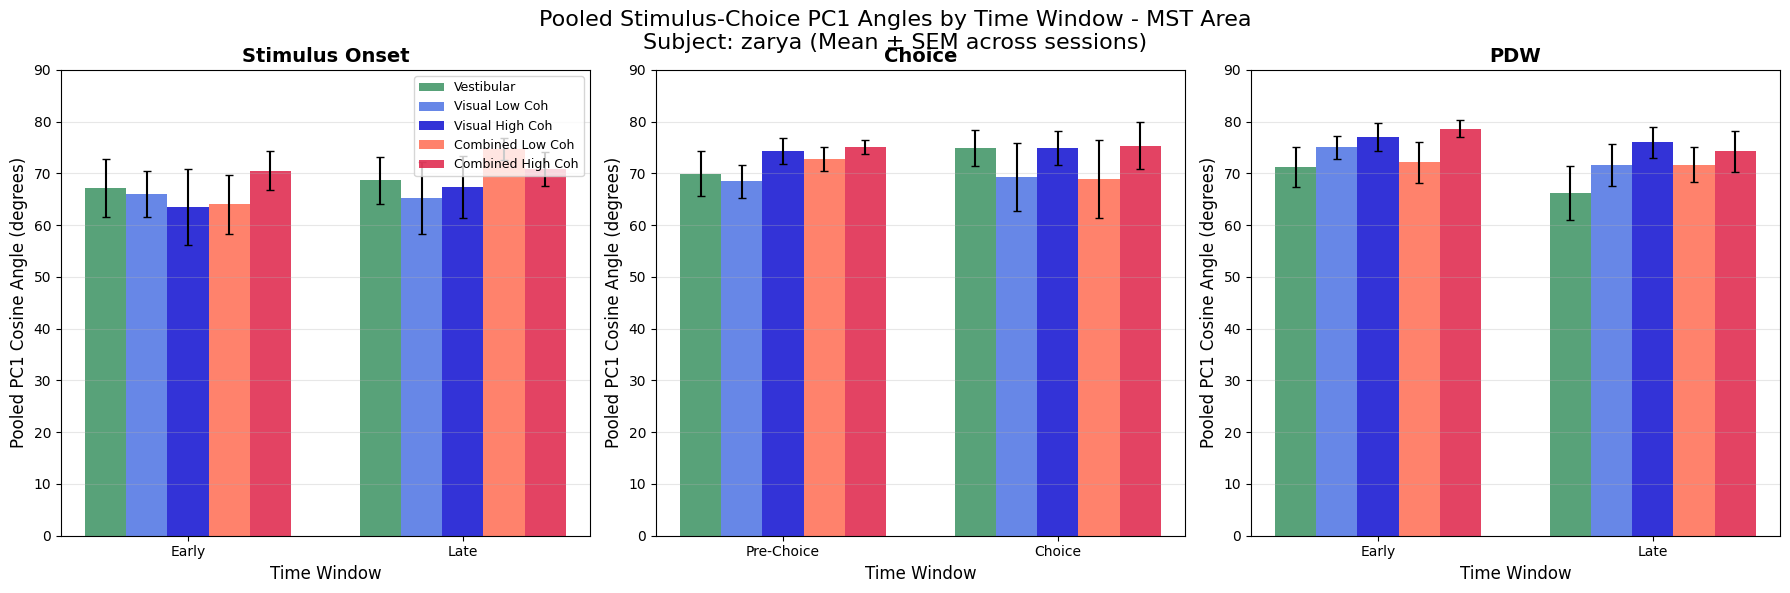


Calculating pooled angle summary for VPS area...
  Processing Vestibular for stimOn...
    Early: 68.8° ± 7.3° (n=6)
    Late: 70.9° ± 9.0° (n=6)
  Processing Visual Low Coh for stimOn...
    Early: 59.6° ± 11.7° (n=6)
    Late: 67.5° ± 12.1° (n=6)
  Processing Visual High Coh for stimOn...
    Early: 67.5° ± 8.8° (n=6)
    Late: 62.4° ± 10.7° (n=6)
  Processing Combined Low Coh for stimOn...
    Early: 66.9° ± 9.3° (n=6)
    Late: 74.0° ± 5.1° (n=6)
  Processing Combined High Coh for stimOn...
    Early: 68.9° ± 3.2° (n=6)
    Late: 70.2° ± 9.2° (n=6)
  Processing Vestibular for saccOnset...
    Pre-Choice: 65.1° ± 12.4° (n=6)
    Choice: 69.4° ± 12.3° (n=6)
  Processing Visual Low Coh for saccOnset...
    Pre-Choice: 67.2° ± 9.9° (n=6)
    Choice: 63.2° ± 8.5° (n=6)
  Processing Visual High Coh for saccOnset...
    Pre-Choice: 71.0° ± 5.7° (n=6)
    Choice: 75.6° ± 3.9° (n=6)
  Processing Combined Low Coh for saccOnset...
    Pre-Choice: 68.9° ± 7.2° (n=6)
    Choice: 70.0° ± 13.9° 

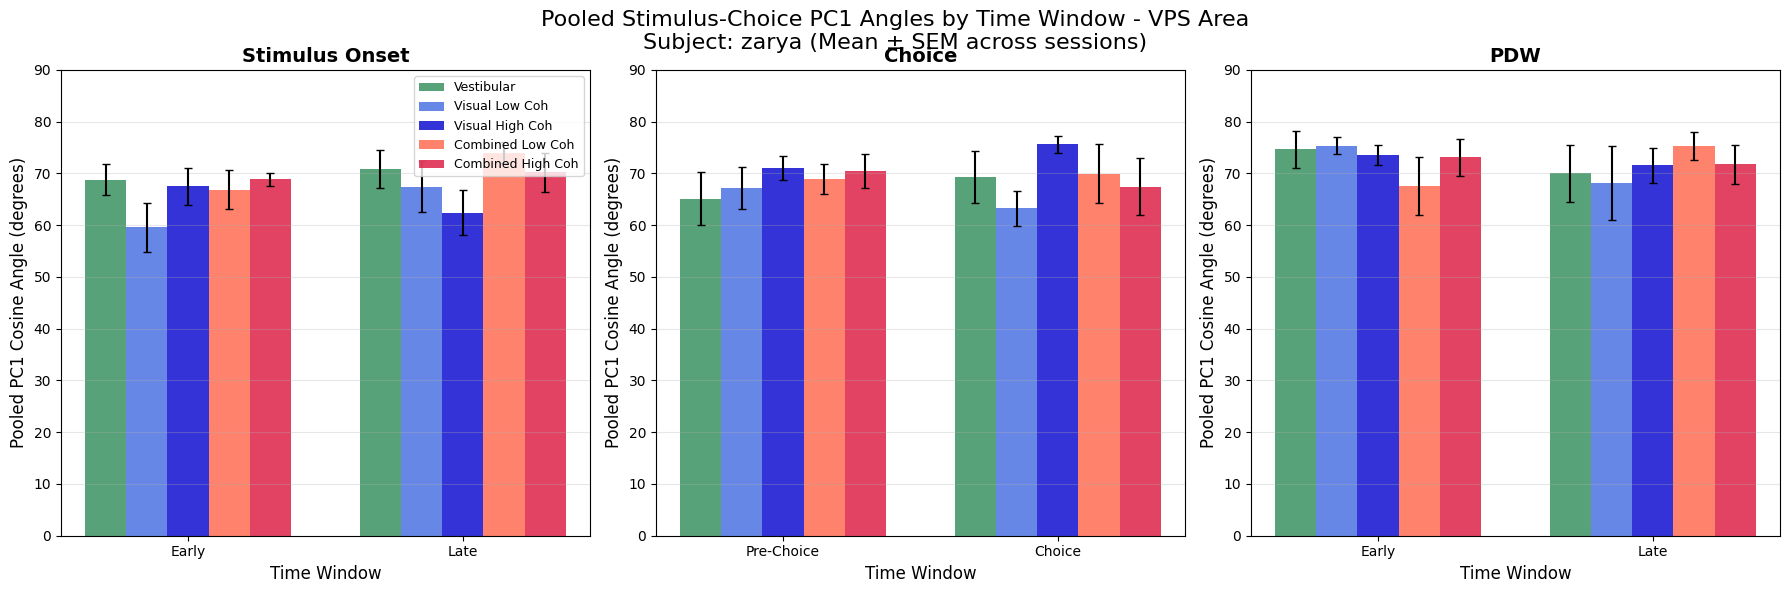


Calculating pooled angle summary for dual area...
  Processing Vestibular for stimOn...
    Early: 75.0° ± 6.1° (n=6)
    Late: 74.8° ± 5.5° (n=6)
  Processing Visual Low Coh for stimOn...
    Early: 73.8° ± 7.6° (n=6)
    Late: 80.5° ± 5.9° (n=6)
  Processing Visual High Coh for stimOn...
    Early: 78.7° ± 5.5° (n=6)
    Late: 79.9° ± 3.7° (n=6)
  Processing Combined Low Coh for stimOn...
    Early: 73.9° ± 6.9° (n=6)
    Late: 82.5° ± 3.1° (n=6)
  Processing Combined High Coh for stimOn...
    Early: 80.0° ± 4.3° (n=6)
    Late: 79.1° ± 7.7° (n=6)
  Processing Vestibular for saccOnset...
    Pre-Choice: 76.1° ± 6.4° (n=6)
    Choice: 79.4° ± 4.6° (n=6)
  Processing Visual Low Coh for saccOnset...
    Pre-Choice: 80.9° ± 3.5° (n=6)
    Choice: 78.1° ± 4.3° (n=6)
  Processing Visual High Coh for saccOnset...
    Pre-Choice: 81.9° ± 5.1° (n=6)
    Choice: 78.7° ± 5.5° (n=6)
  Processing Combined Low Coh for saccOnset...
    Pre-Choice: 79.4° ± 4.5° (n=6)
    Choice: 81.8° ± 3.6° (n=6)

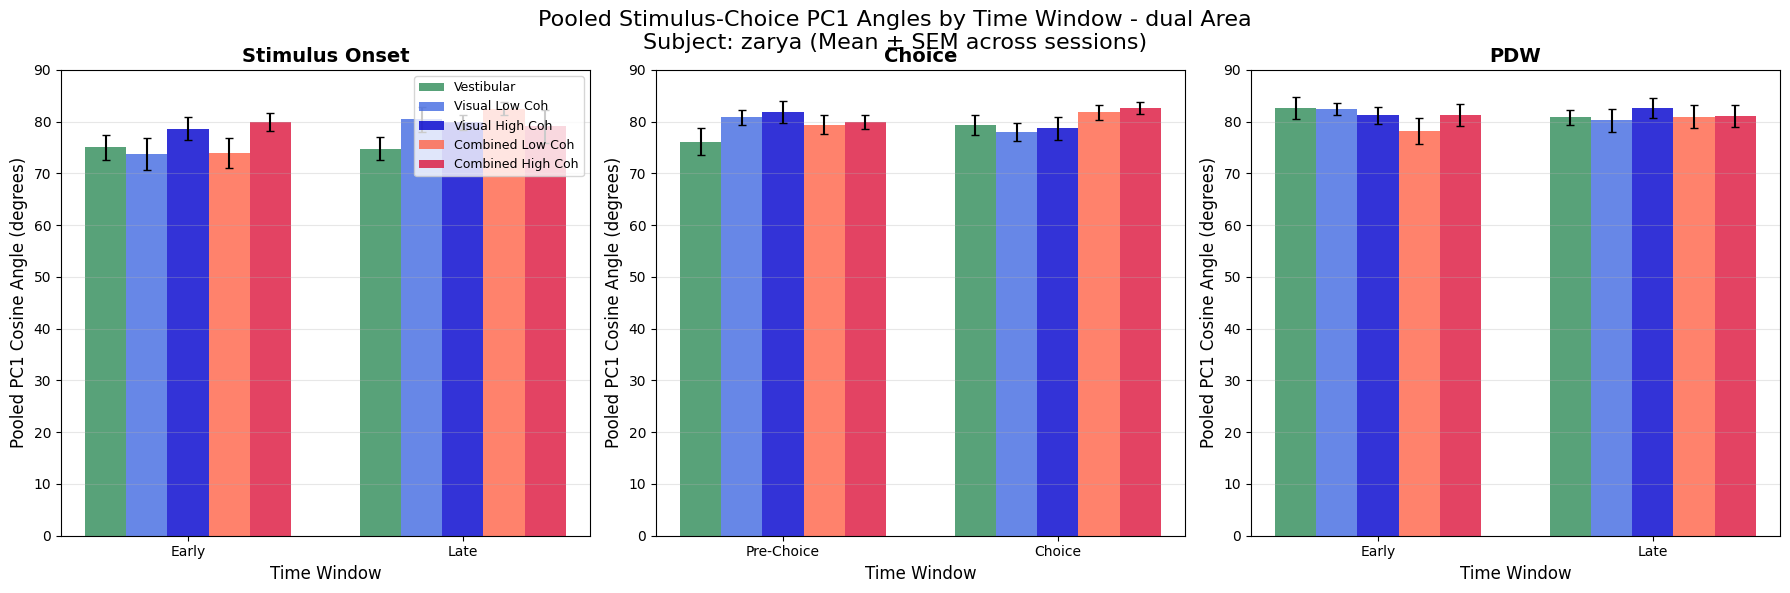


OVERALL SUMMARY: POOLED ANGLES AT ALIGNMENT POINTS (t=0)

MST Area:
------------------------------------------------------------

stimOn (t=0):
  Vestibular          :  63.3° ± 23.5° (n=6)
  Visual Low Coh      :  70.8° ± 11.9° (n=6)
  Visual High Coh     :  59.0° ± 17.3° (n=6)
  Combined Low Coh    :  64.2° ± 14.6° (n=6)
  Combined High Coh   :  64.1° ± 16.9° (n=6)

saccOnset (t=0):
  Vestibular          :  76.3° ± 14.6° (n=6)
  Visual Low Coh      :  67.4° ± 18.2° (n=6)
  Visual High Coh     :  81.9° ±  9.7° (n=6)
  Combined Low Coh    :  64.8° ± 20.0° (n=6)
  Combined High Coh   :  79.5° ± 11.0° (n=6)

postTargHold (t=0):
  Vestibular          :  80.1° ±  6.8° (n=6)
  Visual Low Coh      :  76.8° ± 12.1° (n=6)
  Visual High Coh     :  74.8° ± 13.2° (n=6)
  Combined Low Coh    :  69.3° ± 21.2° (n=6)
  Combined High Coh   :  75.9° ±  5.8° (n=6)

VPS Area:
------------------------------------------------------------

stimOn (t=0):
  Vestibular          :  72.8° ± 11.0° (n=6)
  Visual 

In [37]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

def calculate_pooled_angles_summary(all_results, results_dir, subject):
    """
    Calculate pooled angles at key time points instead of full time series
    """
    
    modality_conditions = {
        'Vestibular': {'mod': 1, 'coh': 1},
        'Visual Low Coh': {'mod': 2, 'coh': 1},
        'Visual High Coh': {'mod': 2, 'coh': 2},
        'Combined Low Coh': {'mod': 3, 'coh': 1},
        'Combined High Coh': {'mod': 3, 'coh': 2}
    }
    
    alignments = ['stimOn', 'saccOnset', 'postTargHold']
    alignment_names = {
        'stimOn': 'Stimulus Onset',
        'saccOnset': 'Choice',
        'postTargHold': 'PDW'
    }
    
    # Define time windows to analyze (relative to alignment)
    time_windows = {
        'stimOn': {
            'Early': (0.0, 0.2),      # 0-200ms after stimulus
            'Late': (0.4, 0.6)        # 400-600ms after stimulus
        },
        'saccOnset': {
            'Pre-Choice': (-0.3, -0.1),  # 300-100ms before choice
            'Choice': (-0.05, 0.05)       # ±50ms around choice
        },
        'postTargHold': {
            'Early': (0.0, 0.2),      # 0-200ms after decision
            'Late': (0.2, 0.4)        # 200-400ms after decision
        }
    }
    
    # Color scheme for conditions
    condition_colors = {
        'Vestibular': '#2E8B57',           # Sea Green
        'Visual Low Coh': '#4169E1',       # Royal Blue
        'Visual High Coh': '#0000CD',      # Medium Blue
        'Combined Low Coh': '#FF6347',     # Tomato
        'Combined High Coh': '#DC143C'     # Crimson
    }
    
    target_areas = ['MST', 'VPS', 'dual']
    
    for area in target_areas:
        if area not in all_results:
            continue
            
        print(f"\nCalculating pooled angle summary for {area} area...")
        
        # Create figure: 3 alignments
        fig, axes = plt.subplots(1, 3, figsize=(18, 6))
        
        for j, alignment in enumerate(alignments):
            ax = axes[j]
            
            # Get time windows for this alignment
            windows = time_windows[alignment]
            window_names = list(windows.keys())
            n_windows = len(window_names)
            
            # Prepare data for bar plot
            condition_names = list(modality_conditions.keys())
            n_conditions = len(condition_names)
            
            # Data storage
            angle_data = np.full((n_conditions, n_windows), np.nan)
            angle_errors = np.full((n_conditions, n_windows), np.nan)
            
            for i, (condition_name, condition_params) in enumerate(modality_conditions.items()):
                mod = condition_params['mod']
                coh = condition_params['coh']
                condition_key = f"mod{mod}_coh{coh}"
                
                print(f"  Processing {condition_name} for {alignment}...")
                
                for w, (window_name, (t_start, t_end)) in enumerate(windows.items()):
                    
                    # Collect angles across sessions for this time window
                    window_angles = []
                    
                    for session_key, session_data in all_results[area].items():
                        if condition_key not in session_data or alignment not in session_data[condition_key]:
                            continue
                        
                        dpca_result = session_data[condition_key][alignment]
                        
                        if 'Z_components' not in dpca_result:
                            continue
                        
                        comp_s = dpca_result['Z_components'].get('s', [])
                        comp_d = dpca_result['Z_components'].get('d', [])
                        
                        if len(comp_s) == 0 or len(comp_d) == 0:
                            continue
                        
                        stim_pc1 = comp_s[0]
                        choice_pc1 = comp_d[0]
                        time_axis = dpca_result['time_axes']
                        
                        # Find time indices for this window
                        window_mask = (time_axis >= t_start) & (time_axis <= t_end)
                        if not np.any(window_mask):
                            continue
                        
                        # Average angle across time window
                        window_angle_series = []
                        for t_idx in np.where(window_mask)[0]:
                            stim_vector = stim_pc1[t_idx, :, :].flatten()
                            choice_vector = choice_pc1[t_idx, :, :].flatten()
                            
                            norm_s = np.linalg.norm(stim_vector)
                            norm_c = np.linalg.norm(choice_vector)
                            
                            if norm_s > 0 and norm_c > 0:
                                cos_sim = np.dot(stim_vector, choice_vector) / (norm_s * norm_c)
                                cos_sim = np.clip(cos_sim, -1, 1)
                                angle = np.degrees(np.arccos(np.abs(cos_sim)))
                                window_angle_series.append(angle)
                        
                        if len(window_angle_series) > 0:
                            # Average across time points in window
                            mean_window_angle = np.mean(window_angle_series)
                            window_angles.append(mean_window_angle)
                    
                    # Store summary statistics
                    if len(window_angles) > 0:
                        angle_data[i, w] = np.mean(window_angles)
                        angle_errors[i, w] = np.std(window_angles) / np.sqrt(len(window_angles))
                        print(f"    {window_name}: {np.mean(window_angles):.1f}° ± {np.std(window_angles):.1f}° (n={len(window_angles)})")
            
            # Create grouped bar plot
            x = np.arange(n_windows)
            width = 0.15
            
            for i, condition_name in enumerate(condition_names):
                color = condition_colors[condition_name]
                offset = (i - n_conditions/2 + 0.5) * width
                
                bars = ax.bar(x + offset, angle_data[i, :], width, 
                             yerr=angle_errors[i, :], 
                             label=condition_name, color=color, alpha=0.8, capsize=3)
            
            # Formatting
            ax.set_xlabel('Time Window', fontsize=12)
            ax.set_ylabel('Pooled PC1 Cosine Angle (degrees)', fontsize=12)
            ax.set_title(f'{alignment_names[alignment]}', fontsize=14, fontweight='bold')
            ax.set_xticks(x)
            ax.set_xticklabels(window_names)
            ax.grid(True, alpha=0.3, axis='y')
            ax.set_ylim([0, 90])
            
            # Legend for first subplot
            if j == 0:
                ax.legend(fontsize=9, loc='upper right')
        
        # Overall title
        fig.suptitle(f'Pooled Stimulus-Choice PC1 Angles by Time Window - {area} Area\n'
                    f'Subject: {subject} (Mean ± SEM across sessions)', 
                     fontsize=16, y=0.98)
        
        plt.tight_layout()
        plt.subplots_adjust(top=0.88)
        
        # Save figure
        save_filename = Path(results_dir) / f"{subject}_{area}_pooled_angles_summary.png"
        plt.savefig(save_filename, dpi=300, bbox_inches='tight')
        print(f"  Figure saved as: {save_filename}")
        
        plt.show()

def create_overall_summary_table(all_results, subject):
    """
    Create a clean summary table of all key results
    """
    
    modality_conditions = {
        'Vestibular': {'mod': 1, 'coh': 1},
        'Visual Low Coh': {'mod': 2, 'coh': 1},
        'Visual High Coh': {'mod': 2, 'coh': 2},
        'Combined Low Coh': {'mod': 3, 'coh': 1},
        'Combined High Coh': {'mod': 3, 'coh': 2}
    }
    
    alignments = ['stimOn', 'saccOnset', 'postTargHold']
    target_areas = ['MST', 'VPS', 'dual']
    
    print(f"\n{'='*80}")
    print(f"OVERALL SUMMARY: POOLED ANGLES AT ALIGNMENT POINTS (t=0)")
    print(f"{'='*80}")
    
    # Create summary table
    summary_table = {}
    
    for area in target_areas:
        if area not in all_results:
            continue
            
        summary_table[area] = {}
        print(f"\n{area} Area:")
        print("-" * 60)
        
        for alignment in alignments:
            summary_table[area][alignment] = {}
            print(f"\n{alignment} (t=0):")
            
            for condition_name, condition_params in modality_conditions.items():
                mod = condition_params['mod']
                coh = condition_params['coh']
                condition_key = f"mod{mod}_coh{coh}"
                
                # Collect angles at t=0
                t0_angles = []
                
                for session_key, session_data in all_results[area].items():
                    if condition_key not in session_data or alignment not in session_data[condition_key]:
                        continue
                    
                    dpca_result = session_data[condition_key][alignment]
                    
                    if 'Z_components' not in dpca_result:
                        continue
                    
                    comp_s = dpca_result['Z_components'].get('s', [])
                    comp_d = dpca_result['Z_components'].get('d', [])
                    
                    if len(comp_s) == 0 or len(comp_d) == 0:
                        continue
                    
                    stim_pc1 = comp_s[0]
                    choice_pc1 = comp_d[0]
                    time_axis = dpca_result['time_axes']
                    
                    # Find t=0
                    t0_idx = np.argmin(np.abs(time_axis))
                    
                    # Calculate pooled angle at t=0
                    stim_vector = stim_pc1[t0_idx, :, :].flatten()
                    choice_vector = choice_pc1[t0_idx, :, :].flatten()
                    
                    norm_s = np.linalg.norm(stim_vector)
                    norm_c = np.linalg.norm(choice_vector)
                    
                    if norm_s > 0 and norm_c > 0:
                        cos_sim = np.dot(stim_vector, choice_vector) / (norm_s * norm_c)
                        cos_sim = np.clip(cos_sim, -1, 1)
                        angle = np.degrees(np.arccos(np.abs(cos_sim)))
                        t0_angles.append(angle)
                
                if len(t0_angles) > 0:
                    mean_angle = np.mean(t0_angles)
                    std_angle = np.std(t0_angles)
                    summary_table[area][alignment][condition_name] = {
                        'mean': mean_angle,
                        'std': std_angle,
                        'n': len(t0_angles)
                    }
                    print(f"  {condition_name:20s}: {mean_angle:5.1f}° ± {std_angle:4.1f}° (n={len(t0_angles)})")
    
    # Print area comparison
    print(f"\n{'='*60}")
    print(f"AREA COMPARISON (Mean across conditions)")
    print(f"{'='*60}")
    
    for alignment in alignments:
        print(f"\n{alignment}:")
        area_means = {}
        for area in target_areas:
            if area in summary_table and alignment in summary_table[area]:
                condition_means = []
                for condition_data in summary_table[area][alignment].values():
                    condition_means.append(condition_data['mean'])
                if condition_means:
                    area_mean = np.mean(condition_means)
                    area_means[area] = area_mean
                    print(f"  {area:8s}: {area_mean:5.1f}°")
    
    return summary_table

# Load functions (same as before)
def load_dpca_results(filepath):
    try:
        data = np.load(filepath, allow_pickle=True)
        if isinstance(data, np.ndarray):
            results = data.item()
        else:
            results = data
        return results
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def load_specific_dates_results(results_dir, subject, dates):
    results_path = Path(results_dir)
    all_results = {}
    
    for date in dates:
        print(f"Loading data for {subject} on {date}...")
        pattern = f"{subject}_{date}_*_dpca_*_results.npy"
        matching_files = list(results_path.glob(pattern))
        
        if not matching_files:
            continue
        
        date_results = {}
        
        for file_path in matching_files:
            parts = file_path.stem.split('_')
            
            try:
                area = parts[2]
                alignment = parts[5]
                mod_part = parts[6]
                coh_part = parts[7]
                
                mod = int(mod_part.replace('mod', ''))
                coh = int(coh_part.replace('coh', ''))
                condition_key = f"mod{mod}_coh{coh}"
                
            except (IndexError, ValueError):
                continue
            
            session_result = load_dpca_results(file_path)
            if session_result is None:
                continue
            
            if area not in date_results:
                date_results[area] = {}
            if condition_key not in date_results[area]:
                date_results[area][condition_key] = {}
            
            date_results[area][condition_key][alignment] = session_result
        
        if date_results:
            session_key = f"{subject}_{date}"
            for area, area_data in date_results.items():
                if area not in all_results:
                    all_results[area] = {}
                all_results[area][session_key] = area_data
    
    return all_results

# Run analysis
results_dir = r"D:\Neural-Pipeline\results\analysis_population\dpca_results"
subject = "zarya"
dates = ["20250602", "20250702", "20250710", "20250523", "20250501", "20250417"]

print("Loading dPCA results...")
all_results = load_specific_dates_results(results_dir, subject, dates)

# Calculate summary with time windows
calculate_pooled_angles_summary(all_results, results_dir, subject)

# Create overall summary table
summary_table = create_overall_summary_table(all_results, subject)

In [41]:
print(results.keys())


dict_keys(['subject', 'date', 'area', 'alignment', 'train_mod', 'train_coh', 'train_delta', 'Z_components', 'variance_explained', 'condition_info', 'time_axes', 'dpca_params', 'analysis_type', 'labels_used'])


### PC1 as the function of time

In [43]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
from matplotlib.backends.backend_pdf import PdfPages

def load_dpca_results(filepath):
    """Safely load dPCA results"""
    try:
        # Load with pickle support
        data = np.load(filepath, allow_pickle=True)
        
        # Convert to dictionary if needed
        if isinstance(data, np.ndarray):
            results = data.item()
        else:
            results = data
            
        return results
        
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def load_specific_dates_results(results_dir, subject, dates):
    """
    Load dPCA results for specific dates and subject
    File pattern: zarya_20250417_MST_dpca_fullspike_stimOn_mod3_coh2_del0_results.npy
    """
    results_path = Path(results_dir)
    all_results = {}
    
    for date in dates:
        print(f"Loading data for {subject} on {date}...")
        
        # Look for files matching the pattern: subject_date_AREA_dpca_*_results.npy
        pattern = f"{subject}_{date}_*_dpca_*_results.npy"
        matching_files = list(results_path.glob(pattern))
        
        if not matching_files:
            print(f"  No files found for {subject} on {date}")
            continue
        
        # Group files by area and organize by condition/alignment
        date_results = {}
        
        for file_path in matching_files:
            print(f"  Loading {file_path.name}...")
            
            # Parse filename to extract info
            # Format: subject_date_area_dpca_fullspike_alignment_modX_cohY_del0_results.npy
            parts = file_path.stem.split('_')
            
            try:
                area = parts[2]  # MST, VPS, etc.
                alignment = parts[5]  # stimOn, saccOnset, postTargHold
                mod_part = parts[6]  # mod1, mod2, mod3
                coh_part = parts[7]  # coh1, coh2
                
                # Extract numbers
                mod = int(mod_part.replace('mod', ''))
                coh = int(coh_part.replace('coh', ''))
                
                condition_key = f"mod{mod}_coh{coh}"
                
                print(f"    Parsed: area={area}, alignment={alignment}, condition={condition_key}")
                
            except (IndexError, ValueError) as e:
                print(f"    Could not parse filename {file_path.name}: {e}")
                continue
            
            # Load the results
            session_result = load_dpca_results(file_path)
            if session_result is None:
                continue
            
            # Initialize nested structure
            if area not in date_results:
                date_results[area] = {}
            if condition_key not in date_results[area]:
                date_results[area][condition_key] = {}
            
            # Store the result
            date_results[area][condition_key][alignment] = session_result
        
        # Add to main results if we found data
        if date_results:
            session_key = f"{subject}_{date}"
            
            for area, area_data in date_results.items():
                if area not in all_results:
                    all_results[area] = {}
                all_results[area][session_key] = area_data
                print(f"    Added {area} area data for {session_key}")
    
    print(f"\nLoaded results for areas: {list(all_results.keys())}")
    for area, sessions in all_results.items():
        print(f"  {area}: {len(sessions)} sessions")
        for session_key, session_data in sessions.items():
            conditions = list(session_data.keys())
            print(f"    {session_key}: {conditions}")
    
    return all_results

def plot_single_session_component(session_key, session_data, comp_type, area, subject):
    """
    Plot a single session and component type
    """
    
    # Define stimulus-specific colors based on DIRECTION (blue = rightward, red = leftward)
    stimulus_colors = {
        1: "#8B0000",    # -10° - dark red (strong leftward)
        2: "#DC143C",    # -3.9° - medium red (medium leftward)  
        3: "#FF6B6B",    # -1.5° - light red (weak leftward)
        4: "#808080",    # 0° - gray (neutral)
        5: "#94C8FF",    # +1.5° - light blue (weak rightward)
        6: "#1E90FF",    # +3.9° - medium blue (medium rightward)
        7: "#0000CF"     # +10° - dark blue (strong rightward)
    }
    
    # Define condition mapping
    modality_conditions = {
        'Vestibular': {'mod': 1, 'coh': 1},
        'Visual Low Coh': {'mod': 2, 'coh': 1},
        'Visual High Coh': {'mod': 2, 'coh': 2},
        'Combined Low Coh': {'mod': 3, 'coh': 1},
        'Combined High Coh': {'mod': 3, 'coh': 2}
    }
    
    alignments = ['stimOn', 'saccOnset', 'postTargHold']
    alignment_names = {
        'stimOn': 'Stimulus Onset',
        'saccOnset': 'Choice',
        'postTargHold': 'PDW'
    }
    
    component_names = {
        's': 'Stimulus',
        'ts': 'Time-Stimulus', 
        'd': 'Choice',
        'td': 'Time-Choice'
    }
    
    # Velocity profile markers for stimOn alignment
    vel_markers = {
        'max_velocity': 0.66,
        'max_acceleration': 0.4,
    }
    
    # Define pre-choice markers
    choice_markers = {
        'pre_choice_early': -0.4,  # 400ms before choice
        'pre_choice_late': -0.2    # 200ms before choice
    }
    
    # Create figure: 5 conditions x 3 alignments
    fig, axes = plt.subplots(5, 3, figsize=(20, 25))  # Increased width for legend
    
    has_data = False
    
    for i, (condition_name, condition_params) in enumerate(modality_conditions.items()):
        mod = condition_params['mod']
        coh = condition_params['coh']
        condition_key = f"mod{mod}_coh{coh}"
        
        for j, alignment in enumerate(alignments):
            ax = axes[i, j]
            
            if condition_key not in session_data or alignment not in session_data[condition_key]:
                ax.text(0.5, 0.5, f'No data', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=10)
                continue
            
            dpca_result = session_data[condition_key][alignment]
            
            if comp_type not in dpca_result['Z_components']:
                ax.text(0.5, 0.5, f'No {comp_type}\ncomponent', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=10)
                continue
                
            # Get first component only
            components = dpca_result['Z_components'][comp_type]
            if len(components) < 1:
                ax.text(0.5, 0.5, f'No components', ha='center', va='center', 
                       transform=ax.transAxes, fontsize=10)
                continue
                
            pc1 = components[0]  # (n_time, n_stimuli, n_choices)
            time_axis = dpca_result['time_axes']
            
            has_data = True
            
            # Plot each stimulus heading (1-7)
            for heading_idx in range(1, 8):  # Headings 1-7
                if heading_idx > pc1.shape[1]:
                    continue
                
                color = stimulus_colors[heading_idx]
                heading_deg = [-10, -3.9, -1.5, 0, 1.5, 3.9, 10][heading_idx-1]
                
                if heading_idx == 4:  # Zero heading - only one line
                    # Average across choices for zero heading
                    pc1_data = np.mean(pc1[:, heading_idx-1, :], axis=1)
                    
                    # Plot PC1 vs Time
                    ax.plot(time_axis, pc1_data, color=color, linewidth=2.5, 
                           alpha=0.8, label=f'{heading_deg}°')
                    
                    # Mark alignment point (t=0) - heading color with black edge
                    t0_idx = np.argmin(np.abs(time_axis))
                    ax.scatter(time_axis[t0_idx], pc1_data[t0_idx], 
                             color=color, s=50, marker='o', edgecolors='black', linewidth=1, zorder=5)
                    
                    # Add velocity markers for stimOn alignment
                    if alignment == 'stimOn':
                        # Add heading-colored dots at max acceleration and max velocity
                        max_acc_idx = np.argmin(np.abs(time_axis - vel_markers['max_acceleration']))
                        max_vel_idx = np.argmin(np.abs(time_axis - vel_markers['max_velocity']))
                        
                        ax.scatter(time_axis[max_acc_idx], pc1_data[max_acc_idx], 
                                 color=color, s=40, marker='o', edgecolors='black', linewidth=1, zorder=5)
                        ax.scatter(time_axis[max_vel_idx], pc1_data[max_vel_idx], 
                                 color=color, s=40, marker='o', edgecolors='black', linewidth=1, zorder=5)
                    
                    # Add pre-choice markers for saccOnset alignment
                    if alignment == 'saccOnset':
                        # Add heading-colored dots at pre-choice time points
                        early_idx = np.argmin(np.abs(time_axis - choice_markers['pre_choice_early']))
                        late_idx = np.argmin(np.abs(time_axis - choice_markers['pre_choice_late']))
                        
                        ax.scatter(time_axis[early_idx], pc1_data[early_idx], 
                                 color=color, s=40, marker='o', edgecolors='black', linewidth=1, zorder=5)
                        ax.scatter(time_axis[late_idx], pc1_data[late_idx], 
                                 color=color, s=40, marker='o', edgecolors='black', linewidth=1, zorder=5)
                
                else:  # Non-zero headings - correct and error trials
                    # Determine correct choice for this heading
                    if heading_idx <= 3:  # Negative headings (1,2,3) - leftward direction
                        correct_choice = 0  # Left choice is correct
                        error_choice = 1    # Right choice is error
                    else:  # Positive headings (5,6,7) - rightward direction
                        correct_choice = 1  # Right choice is correct  
                        error_choice = 0    # Left choice is error
                    
                    # Get data for correct and error trials
                    pc1_correct = pc1[:, heading_idx-1, correct_choice]
                    pc1_error = pc1[:, heading_idx-1, error_choice]
                    
                    # Plot correct trials (solid line)
                    ax.plot(time_axis, pc1_correct, color=color, linewidth=3, 
                           linestyle='-', alpha=0.9, label=f'{heading_deg}° Correct')
                    
                    # Plot error trials (dashed line, thinner and more transparent)
                    ax.plot(time_axis, pc1_error, color=color, linewidth=1.5, 
                           linestyle='--', alpha=0.9, label=f'{heading_deg}° Error')
                    
                    # Mark alignment points (t=0) - ONLY for correct trials, heading color with black edge
                    t0_idx = np.argmin(np.abs(time_axis))
                    ax.scatter(time_axis[t0_idx], pc1_correct[t0_idx], 
                             color=color, s=50, marker='o', edgecolors='black', linewidth=1, zorder=5)
                    
                    # Add velocity markers for stimOn alignment
                    if alignment == 'stimOn':
                        # Add heading-colored dots at max acceleration and max velocity for correct trials
                        max_acc_idx = np.argmin(np.abs(time_axis - vel_markers['max_acceleration']))
                        max_vel_idx = np.argmin(np.abs(time_axis - vel_markers['max_velocity']))
                        
                        ax.scatter(time_axis[max_acc_idx], pc1_correct[max_acc_idx], 
                                 color=color, s=40, marker='o', edgecolors='black', linewidth=1, zorder=5)
                        ax.scatter(time_axis[max_vel_idx], pc1_correct[max_vel_idx], 
                                 color=color, s=40, marker='o', edgecolors='black', linewidth=1, zorder=5)
                    
                    # Add pre-choice markers for saccOnset alignment
                    if alignment == 'saccOnset':
                        # Add heading-colored dots at pre-choice time points for correct trials
                        early_idx = np.argmin(np.abs(time_axis - choice_markers['pre_choice_early']))
                        late_idx = np.argmin(np.abs(time_axis - choice_markers['pre_choice_late']))
                        
                        ax.scatter(time_axis[early_idx], pc1_correct[early_idx], 
                                 color=color, s=40, marker='o', edgecolors='black', linewidth=1, zorder=5)
                        ax.scatter(time_axis[late_idx], pc1_correct[late_idx], 
                                 color=color, s=40, marker='o', edgecolors='black', linewidth=1, zorder=5)
            
            # Add velocity markers for stimOn alignment with text annotations
            if alignment == 'stimOn':
                ax.axvline(x=vel_markers['max_acceleration'], color='orange', linestyle=':', alpha=0.7)
                ax.axvline(x=vel_markers['max_velocity'], color='purple', linestyle=':', alpha=0.7)
                
                # Add text annotations at the top of the plot
                ax.text(vel_markers['max_acceleration'], 0.95, 'Max Acc', 
                       rotation=90, verticalalignment='top', horizontalalignment='right',
                       color='orange', fontsize=10, transform=ax.get_xaxis_transform())
                ax.text(vel_markers['max_velocity'], 0.95, 'Max Vel', 
                       rotation=90, verticalalignment='top', horizontalalignment='right',
                       color='purple', fontsize=10, transform=ax.get_xaxis_transform())
            
            # Add pre-choice markers for saccOnset alignment with text annotations
            if alignment == 'saccOnset':
                ax.axvline(x=choice_markers['pre_choice_early'], color='green', linestyle=':', alpha=0.7)
                ax.axvline(x=choice_markers['pre_choice_late'], color='cyan', linestyle=':', alpha=0.7)
                
                # Add text annotations at the top of the plot
                ax.text(choice_markers['pre_choice_early'], 0.95, '-400ms', 
                       rotation=90, verticalalignment='top', horizontalalignment='right',
                       color='green', fontsize=10, transform=ax.get_xaxis_transform())
                ax.text(choice_markers['pre_choice_late'], 0.95, '-200ms', 
                       rotation=90, verticalalignment='top', horizontalalignment='right',
                       color='cyan', fontsize=10, transform=ax.get_xaxis_transform())
            
            # Formatting
            ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
            ax.axvline(x=0, color='gray', linestyle='--', alpha=0.5, linewidth=2)
            
            ax.set_xlabel('Time (s)', fontsize=12)
            ax.set_ylabel(f'{comp_type.upper()} PC1', fontsize=12)
            
            # Title for top row
            if i == 0:
                ax.set_title(f'{alignment_names[alignment]}', fontsize=14, fontweight='bold')
            
            # Condition label for leftmost column
            if j == 0:
                ax.text(-0.15, 0.5, condition_name, rotation=90, 
                       verticalalignment='center', horizontalalignment='center',
                       transform=ax.transAxes, fontsize=12, fontweight='bold')
            
            ax.grid(True, alpha=0.3)
            ax.tick_params(axis='both', which='major', labelsize=10)
    
    if not has_data:
        plt.close(fig)
        return None
    
    # Create legend outside the plots (moved further right)
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='black', linewidth=3, linestyle='-', label='Correct Trials'),
        Line2D([0], [0], color='black', linewidth=1.5, linestyle='--', label='Error Trials'),
        Line2D([0], [0], color='#0000CF', linewidth=2, label='Rightward Direction'),
        Line2D([0], [0], color='#808080', linewidth=2, label='Zero Direction'),
        Line2D([0], [0], color='#8B0000', linewidth=2, label='Leftward Direction'),
        Line2D([0], [0], color='gray', marker='o', linestyle='None', markersize=6, 
               markeredgecolor='black', markeredgewidth=1, label='Time Markers')
    ]
    
    # Position legend further to the right
    fig.legend(handles=legend_elements, loc='center right', bbox_to_anchor=(1.02, 0.5), 
              fontsize=12, frameon=True, fancybox=True, shadow=True)
    
    # Overall title
    fig.suptitle(f'{component_names[comp_type]} Component: PC1 vs Time - {area} Area\n'
                f'Subject: {subject}, Session: {session_key}\n'
                f'Solid=Correct, Dashed=Error, Blue=Rightward, Red=Leftward', 
                 fontsize=16, y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92, left=0.06, right=0.80)  # More room for legend
    
    return fig

def plot_dpca_pc1_vs_time_to_pdf(all_results, results_dir, subject):
    """
    Plot dPCA PC1 components vs Time and save to organized PDFs
    """
    
    # Define areas to plot
    target_areas = ['MST', 'VPS', 'dual']
    
    # Component groupings for PDFs
    component_groups = {
        'stimulus': ['s', 'ts'],  # Stimulus and Time-Stimulus
        'choice': ['d', 'td']     # Choice and Time-Choice
    }
    
    component_names = {
        's': 'Stimulus',
        'ts': 'Time-Stimulus', 
        'd': 'Choice',
        'td': 'Time-Choice'
    }
    
    for area in target_areas:
        if area not in all_results:
            print(f"No data found for {area} area")
            continue
            
        print(f"\nCreating PC1 vs Time dPCA plots for {area} area...")
        
        # Create PDFs for each component group
        for group_name, comp_types in component_groups.items():
            pdf_filename = Path(results_dir) / f"{subject}_{area}_dpca_{group_name}_components_pc1_vs_time.pdf"
            
            with PdfPages(pdf_filename) as pdf:
                print(f"  Creating {group_name} components PDF: {pdf_filename}")
                
                # Process each session
                for session_key, session_data in all_results[area].items():
                    print(f"    Processing session: {session_key}")
                    
                    # Process each component type in this group
                    for comp_type in comp_types:
                        print(f"      Processing {comp_type} component...")
                        
                        fig = plot_single_session_component(session_key, session_data, comp_type, area, subject)
                        
                        if fig is not None:
                            pdf.savefig(fig, dpi=300, bbox_inches='tight')
                            plt.close(fig)  # Close to save memory
                        else:
                            print(f"        No data for {comp_type} component in {session_key}")
                
                print(f"  Saved {group_name} components PDF for {area} area")

# Set parameters and run
results_dir = r"D:\Neural-Pipeline\results\analysis_population\dpca_results"
subject = "zarya"
dates = ["20250602", "20250702", "20250710", "20250523", "20250501", "20250417"]

# Load results for specific dates
print(f"Loading dPCA results for {subject}...")
all_results = load_specific_dates_results(results_dir, subject, dates)

# Plot PC1 vs Time and save to organized PDFs
plot_dpca_pc1_vs_time_to_pdf(all_results, results_dir, subject)

print("All PDFs have been created!")

Loading dPCA results for zarya...
Loading data for zarya on 20250602...
  Loading zarya_20250602_dual_dpca_fullspike_postTargHold_mod1_coh1_del0_results.npy...
    Parsed: area=dual, alignment=postTargHold, condition=mod1_coh1
  Loading zarya_20250602_dual_dpca_fullspike_postTargHold_mod2_coh1_del0_results.npy...
    Parsed: area=dual, alignment=postTargHold, condition=mod2_coh1
  Loading zarya_20250602_dual_dpca_fullspike_postTargHold_mod2_coh2_del0_results.npy...
    Parsed: area=dual, alignment=postTargHold, condition=mod2_coh2
  Loading zarya_20250602_dual_dpca_fullspike_postTargHold_mod3_coh1_del0_results.npy...
    Parsed: area=dual, alignment=postTargHold, condition=mod3_coh1
  Loading zarya_20250602_dual_dpca_fullspike_postTargHold_mod3_coh2_del0_results.npy...
    Parsed: area=dual, alignment=postTargHold, condition=mod3_coh2
  Loading zarya_20250602_dual_dpca_fullspike_saccOnset_mod1_coh1_del0_results.npy...
    Parsed: area=dual, alignment=saccOnset, condition=mod1_coh1
  Lo

### SFN PC as the function of time

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import re
from matplotlib.backends.backend_pdf import PdfPages

def load_dpca_results(filepath):
    """Safely load dPCA results"""
    try:
        # Load with pickle support
        data = np.load(filepath, allow_pickle=True)
        
        # Convert to dictionary if needed
        if isinstance(data, np.ndarray):
            results = data.item()
        else:
            results = data
            
        return results
        
    except Exception as e:
        print(f"Error loading {filepath}: {e}")
        return None

def load_specific_dates_results(results_dir, subject, dates):
    """
    Load dPCA results for specific dates and subject
    File pattern: zarya_20250417_MST_dpca_fullspike_stimOn_mod3_coh2_del0_results.npy
    """
    results_path = Path(results_dir)
    all_results = {}
    
    for date in dates:
        print(f"Loading data for {subject} on {date}...")
        
        # Look for files matching the pattern: subject_date_AREA_dpca_*_results.npy
        pattern = f"{subject}_{date}_*_dpca_*_results.npy"
        matching_files = list(results_path.glob(pattern))
        
        if not matching_files:
            print(f"  No files found for {subject} on {date}")
            continue
        
        # Group files by area and organize by condition/alignment
        date_results = {}
        
        for file_path in matching_files:
            print(f"  Loading {file_path.name}...")
            
            # Parse filename to extract info
            # Format: subject_date_area_dpca_fullspike_alignment_modX_cohY_del0_results.npy
            parts = file_path.stem.split('_')
            
            try:
                area = parts[2]  # MST, VPS, etc.
                alignment = parts[5]  # stimOn, saccOnset, postTargHold
                mod_part = parts[6]  # mod1, mod2, mod3
                coh_part = parts[7]  # coh1, coh2
                
                # Extract numbers
                mod = int(mod_part.replace('mod', ''))
                coh = int(coh_part.replace('coh', ''))
                
                condition_key = f"mod{mod}_coh{coh}"
                
                print(f"    Parsed: area={area}, alignment={alignment}, condition={condition_key}")
                
            except (IndexError, ValueError) as e:
                print(f"    Could not parse filename {file_path.name}: {e}")
                continue
            
            # Load the results
            session_result = load_dpca_results(file_path)
            if session_result is None:
                continue
            
            # Initialize nested structure
            if area not in date_results:
                date_results[area] = {}
            if condition_key not in date_results[area]:
                date_results[area][condition_key] = {}
            
            # Store the result
            date_results[area][condition_key][alignment] = session_result
        
        # Add to main results if we found data
        if date_results:
            session_key = f"{subject}_{date}"
            
            for area, area_data in date_results.items():
                if area not in all_results:
                    all_results[area] = {}
                all_results[area][session_key] = area_data
                print(f"    Added {area} area data for {session_key}")
    
    print(f"\nLoaded results for areas: {list(all_results.keys())}")
    for area, sessions in all_results.items():
        print(f"  {area}: {len(sessions)} sessions")
        for session_key, session_data in sessions.items():
            conditions = list(session_data.keys())
            print(f"    {session_key}: {conditions}")
    
    return all_results

def plot_single_session_component(session_key, session_data, comp_type, area, subject):
    """
    Plot a single session and component type using orange/teal color scheme
    Pool stimulus and saccade alignments in the same plot with proper time axes
    """
    
    # Define heading-specific colors using orange/teal scheme
    # Orange for leftward (negative), Teal for rightward (positive)
    # Darker = larger magnitude, Lighter = smaller magnitude
    heading_colors = {
        1: "#803300",    # -10° - very dark orange (strong leftward) - RGB(0.5, 0.2, 0.0)
        2: "#CC6600",    # -3.9° - medium orange (medium leftward) - RGB(0.8, 0.4, 0.0)
        3: "#FFB366",    # -1.5° - light orange (weak leftward)
        4: "#808080",    # 0° - gray (neutral)
        5: "#66CCCC",    # +1.5° - light teal (weak rightward)
        6: "#008080",    # +3.9° - medium teal (medium rightward) - RGB(0.0, 0.5, 0.5)
        7: "#004D4D"     # +10° - very dark teal (strong rightward) - RGB(0.0, 0.3, 0.3)
    }
    
    # Heading values for labels
    heading_values = {
        1: -10.0,
        2: -3.9,
        3: -1.5,
        4: 0.0,
        5: 1.5,
        6: 3.9,
        7: 10.0
    }
    
    # Define condition mapping - consistent with decoder plots
    modality_conditions = {
        'Vestibular Only': {'mod': 1, 'coh': 1},
        'Visual Low Coh': {'mod': 2, 'coh': 1},
        'Visual High Coh': {'mod': 2, 'coh': 2},
        'Combined Low Coh': {'mod': 3, 'coh': 1},
        'Combined High Coh': {'mod': 3, 'coh': 2}
    }
    
    # Define alignments
    alignments = ['stimOn', 'saccOnset']
    
    component_names = {
        's': 'Stimulus',
        'ts': 'Time-Stimulus', 
        'd': 'Choice',
        'td': 'Time-Choice'
    }
    
    # Create figure: 5 conditions x 1 column (pooled alignments)
    fig, axes = plt.subplots(5, 1, figsize=(16, 25))
    if len(modality_conditions) == 1:
        axes = [axes]
    
    has_data = False
    
    for i, (condition_name, condition_params) in enumerate(modality_conditions.items()):
        mod = condition_params['mod']
        coh = condition_params['coh']
        condition_key = f"mod{mod}_coh{coh}"
        
        print(f"\n  {condition_name} (mod={mod}, coh={coh}):")
        
        ax = axes[i]
        
        # Check if we have data for both alignments
        stim_data = None
        sacc_data = None
        
        if condition_key in session_data:
            if 'stimOn' in session_data[condition_key]:
                stim_result = session_data[condition_key]['stimOn']
                if comp_type in stim_result['Z_components'] and len(stim_result['Z_components'][comp_type]) > 0:
                    stim_data = {
                        'pc1': stim_result['Z_components'][comp_type][0],
                        'time': stim_result['time_axes']
                    }
            
            if 'saccOnset' in session_data[condition_key]:
                sacc_result = session_data[condition_key]['saccOnset']
                if comp_type in sacc_result['Z_components'] and len(sacc_result['Z_components'][comp_type]) > 0:
                    sacc_data = {
                        'pc1': sacc_result['Z_components'][comp_type][0],
                        'time': sacc_result['time_axes']
                    }
        
        if stim_data is None and sacc_data is None:
            ax.text(0.5, 0.5, f'No data', ha='center', va='center', 
                   transform=ax.transAxes, fontsize=12)
            ax.set_title(f'{condition_name}', fontsize=16, fontweight='bold', loc='left')
            continue
        
        has_data = True
        print(f"    Processing pooled alignments...")
        
        # Set up time axes similar to decoder analysis
        gap_size = 5  # Gap between alignments (in index units)
        
        # Process stimulus data (left side)
        stimon_indices = []
        stimon_time_axis = []
        if stim_data is not None:
            stimon_time_axis = stim_data['time']
            stimon_indices = np.arange(len(stimon_time_axis))
        
        # Process saccade data (right side) - trim to start from -400ms
        saccade_indices = []
        saccade_time_axis_trimmed = []
        saccade_start_idx = 0
        if sacc_data is not None:
            saccade_time_axis = sacc_data['time']
            # Find index where time >= -0.4 (start from -400ms)
            saccade_start_idx = np.where(saccade_time_axis >= -0.4)[0]
            if len(saccade_start_idx) > 0:
                saccade_start_idx = saccade_start_idx[0]
                saccade_time_axis_trimmed = saccade_time_axis[saccade_start_idx:]
                saccade_indices = np.arange(len(saccade_time_axis_trimmed)) + len(stimon_indices) + gap_size
        
        # Create combined indices and time labels for x-axis
        combined_indices = []
        combined_time_labels = []
        if len(stimon_indices) > 0:
            combined_indices.extend(stimon_indices)
            combined_time_labels.extend(stimon_time_axis)
        if len(saccade_indices) > 0:
            combined_indices.extend(saccade_indices)
            combined_time_labels.extend(saccade_time_axis_trimmed)
        
        # Process stimulus data (left side - align to stimulus onset)
        if stim_data is not None:
            stim_pc1 = stim_data['pc1']  # (n_time, n_stimuli, n_choices)
            
            # Plot each heading for stimulus alignment
            for heading_idx in range(1, 8):
                if heading_idx > stim_pc1.shape[1]:
                    continue
                
                color = heading_colors[heading_idx]
                heading_deg = heading_values[heading_idx]
                
                if heading_idx == 4:  # Zero heading - only one line
                    pc1_data = np.mean(stim_pc1[:, heading_idx-1, :], axis=1)
                    ax.plot(stimon_indices, pc1_data, color=color, linewidth=3, 
                           alpha=0.9, label=f'{heading_deg}°')
                else:
                    # Determine correct choice
                    if heading_idx <= 3:
                        correct_choice = 0
                        error_choice = 1
                    else:
                        correct_choice = 1
                        error_choice = 0
                    
                    pc1_correct = stim_pc1[:, heading_idx-1, correct_choice]
                    pc1_error = stim_pc1[:, heading_idx-1, error_choice]
                    
                    ax.plot(stimon_indices, pc1_correct, color=color, linewidth=3, 
                           linestyle='-', alpha=0.9, label=f'{heading_deg}° Correct' if heading_idx == 1 else "")
                    ax.plot(stimon_indices, pc1_error, color=color, linewidth=2, 
                           linestyle='--', alpha=0.7, label=f'{heading_deg}° Error' if heading_idx == 1 else "")
        
        # Process saccade data (right side - align to saccade onset, use trimmed data)
        if sacc_data is not None and len(saccade_indices) > 0:
            sacc_pc1 = sacc_data['pc1']  # (n_time, n_stimuli, n_choices)
            
            # Trim saccade data to match time axis
            sacc_pc1_trimmed = sacc_pc1[saccade_start_idx:, :, :]
            
            # Plot each heading for saccade alignment
            for heading_idx in range(1, 8):
                if heading_idx > sacc_pc1_trimmed.shape[1]:
                    continue
                
                color = heading_colors[heading_idx]
                heading_deg = heading_values[heading_idx]
                
                if heading_idx == 4:  # Zero heading
                    pc1_data = np.mean(sacc_pc1_trimmed[:, heading_idx-1, :], axis=1)
                    ax.plot(saccade_indices, pc1_data, color=color, linewidth=3, 
                           alpha=0.9)
                else:
                    # Determine correct choice
                    if heading_idx <= 3:
                        correct_choice = 0
                        error_choice = 1
                    else:
                        correct_choice = 1
                        error_choice = 0
                    
                    pc1_correct = sacc_pc1_trimmed[:, heading_idx-1, correct_choice]
                    pc1_error = sacc_pc1_trimmed[:, heading_idx-1, error_choice]
                    
                    ax.plot(saccade_indices, pc1_correct, color=color, linewidth=3, 
                           linestyle='-', alpha=0.9)
                    ax.plot(saccade_indices, pc1_error, color=color, linewidth=2, 
                           linestyle='--', alpha=0.7)
                    
                    all_lines = ax.get_lines()
                    for line in all_lines:
                        if line.get_linestyle() == '-':
                            line.set_linewidth(6)
                        elif line.get_linestyle() == '--':
                            line.set_linewidth(5)
                            
                            # Formatting
                            ax.spines['top'].set_visible(False)
                            ax.spines['right'].set_visible(False)
                            ax.spines['left'].set_linewidth(2)
                            ax.spines['bottom'].set_linewidth(2)
                            ax.tick_params(width=2, labelsize=12)
        
        # Add reference lines
        ax.axhline(y=0, color='gray', linestyle='--', alpha=0.5, linewidth=2)
        
        # Add alignment markers
        if len(stimon_indices) > 0:
            # Stimulus onset marker (solid line)
            stimon_zero_idx = np.where(np.array(stimon_time_axis) >= 0)[0]
            if len(stimon_zero_idx) > 0:
                stimon_zero_idx = stimon_zero_idx[0]
                ax.axvline(x=stimon_zero_idx, color='black', linestyle='--', alpha=0.8, linewidth=4)
        
        if len(saccade_indices) > 0:
            # Saccade onset marker (dashed line)
            saccade_zero_idx = np.where(np.array(saccade_time_axis_trimmed) >= 0)[0]
            if len(saccade_zero_idx) > 0:
                saccade_zero_idx = saccade_indices[0] + saccade_zero_idx[0]
                ax.axvline(x=saccade_zero_idx, color='red', linestyle='--', alpha=0.8, linewidth=4)
        
        # Set custom x-axis ticks and labels
        if combined_indices:
            # Define the specific time values you want to show
            target_times = [-0.1, -0.4, 0, 0.4]
            
            # Find indices closest to your target times
            tick_indices = []
            tick_labels = []
            
            for target_time in target_times:
                # Find the index of the closest time value
                closest_idx = min(range(len(combined_time_labels)), 
                                key=lambda i: abs(combined_time_labels[i] - target_time))
                
                # Only add if the closest value is reasonably close (within some tolerance)
                if abs(combined_time_labels[closest_idx] - target_time) < 0.01:  # adjust tolerance as needed
                    tick_indices.append(combined_indices[closest_idx])
                    tick_labels.append(f'{target_time:.1f}')
            
            ax.set_xticks(tick_indices)
            ax.set_xticklabels(tick_labels)
        
        ax.set_xlabel('Time (s)', fontsize=14, fontweight='bold')
        ax.set_ylabel(f'{component_names[comp_type]} PC1', fontsize=14, fontweight='bold')
        ax.set_title(f'{condition_name}', fontsize=16, fontweight='bold', loc='left')
        
        # Add legend to bottom subplot
        if i == len(modality_conditions) - 1:
            from matplotlib.lines import Line2D
            legend_elements = [
                Line2D([0], [0], color='black', linewidth=3, linestyle='-', label='Correct Trials'),
                Line2D([0], [0], color='black', linewidth=2, linestyle='--', label='Error Trials'),
                Line2D([0], [0], color='black', linewidth=3, linestyle='-', alpha=0.8, label='Stim Onset'),
                Line2D([0], [0], color='black', linewidth=3, linestyle='--', alpha=0.8, label='Saccade Onset'),
                Line2D([0], [0], color='#004D4D', linewidth=3, label='Rightward (+)'),
                Line2D([0], [0], color='#808080', linewidth=3, label='Zero (0°)'),
                Line2D([0], [0], color='#803300', linewidth=3, label='Leftward (-)'),
            ]
            ax.legend(handles=legend_elements, fontsize=12, prop={'weight': 'bold'}, 
                     bbox_to_anchor=(1.05, 1), loc='upper left')
    
    if not has_data:
        plt.close(fig)
        return None
    
    # Overall title
    fig.suptitle(f'{component_names[comp_type]} Component: PC1 vs Time (Pooled Alignments) - {area} Area\n'
                f'Subject: {subject}, Session: {session_key}\n'
                f'Orange=Leftward, Teal=Rightward, Darker=Larger Magnitude', 
                 fontsize=18, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.95, left=0.08, right=0.85)
    
    return fig

def plot_dpca_pc1_vs_time_to_pdf(all_results, results_dir, subject):
    """
    Plot dPCA PC1 components vs Time and save to organized PDFs
    """
    
    # Define areas to plot
    target_areas = ['MST', 'VPS', 'dual']
    
    # Component groupings for PDFs
    component_groups = {
        'stimulus': ['s', 'ts'],  # Stimulus and Time-Stimulus
        'choice': ['d', 'td']     # Choice and Time-Choice
    }
    
    component_names = {
        's': 'Stimulus',
        'ts': 'Time-Stimulus', 
        'd': 'Choice',
        'td': 'Time-Choice'
    }
    
    for area in target_areas:
        if area not in all_results:
            print(f"No data found for {area} area")
            continue
            
        print(f"\nCreating PC1 vs Time dPCA plots for {area} area...")
        
        # Create PDFs for each component group
        for group_name, comp_types in component_groups.items():
            pdf_filename = Path(results_dir) / f"{subject}_{area}_dpca_{group_name}_components_pc1_vs_time_orange_teal.pdf"
            
            with PdfPages(pdf_filename) as pdf:
                print(f"  Creating {group_name} components PDF: {pdf_filename}")
                
                # Process each session
                for session_key, session_data in all_results[area].items():
                    print(f"    Processing session: {session_key}")
                    
                    # Process each component type in this group
                    for comp_type in comp_types:
                        print(f"      Processing {comp_type} component...")
                        
                        fig = plot_single_session_component(session_key, session_data, comp_type, area, subject)
                        
                        if fig is not None:
                            pdf.savefig(fig, dpi=300, bbox_inches='tight')
                            plt.close(fig)  # Close to save memory
                        else:
                            print(f"        No data for {comp_type} component in {session_key}")
                
                print(f"  Saved {group_name} components PDF for {area} area")

# Set parameters and run
results_dir = r"D:\Neural-Pipeline\results\analysis_population\dpca_results"
subject = "zarya"
dates = ["20250602", "20250702", "20250710", "20250523", "20250501", "20250417"]

# Load results for specific dates
print(f"Loading dPCA results for {subject}...")
all_results = load_specific_dates_results(results_dir, subject, dates)

# Plot PC1 vs Time and save to organized PDFs
plot_dpca_pc1_vs_time_to_pdf(all_results, results_dir, subject)

print("All PDFs have been created with orange/teal color scheme!")

Loading dPCA results for zarya...
Loading data for zarya on 20250602...
  Loading zarya_20250602_dual_dpca_fullspike_postTargHold_mod1_coh1_del0_results.npy...
    Parsed: area=dual, alignment=postTargHold, condition=mod1_coh1
  Loading zarya_20250602_dual_dpca_fullspike_postTargHold_mod2_coh1_del0_results.npy...
    Parsed: area=dual, alignment=postTargHold, condition=mod2_coh1
  Loading zarya_20250602_dual_dpca_fullspike_postTargHold_mod2_coh2_del0_results.npy...
    Parsed: area=dual, alignment=postTargHold, condition=mod2_coh2
  Loading zarya_20250602_dual_dpca_fullspike_postTargHold_mod3_coh1_del0_results.npy...
    Parsed: area=dual, alignment=postTargHold, condition=mod3_coh1
  Loading zarya_20250602_dual_dpca_fullspike_postTargHold_mod3_coh2_del0_results.npy...
    Parsed: area=dual, alignment=postTargHold, condition=mod3_coh2
  Loading zarya_20250602_dual_dpca_fullspike_saccOnset_mod1_coh1_del0_results.npy...
    Parsed: area=dual, alignment=saccOnset, condition=mod1_coh1
  Lo